<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/ICG_subcomplexes/HC_full_code_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Libraries

In [1]:
!pip install tslearn

In [2]:
!pip install pyclustering

In [3]:
!pip install kneed

In [4]:
# --- Librerías científicas y de manejo de datos ---
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.signal as signal
from scipy.signal import butter, filtfilt, savgol_filter, find_peaks, argrelextrema
from scipy.stats import skew, kurtosis
from scipy.spatial.distance import pdist, squareform
from scipy.ndimage import gaussian_filter1d

# --- Machine Learning ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split

# --- Clustering y series temporales ---
from pyclustering.cluster.kmedoids import kmedoids
from tslearn.metrics import cdist_dtw
from kneed import KneeLocator

# --- Visualización ---
import matplotlib.pyplot as plt

# --- Progreso y visualización interactiva ---
from tqdm import tqdm
import ipywidgets as widgets
from IPython.display import display

# --- Otros ---
import os
import random
import h5py
from itertools import combinations
from google.colab import drive


###General Algorithm

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Procesando 59146239: 100%|██████████| 184/184 [00:18<00:00, 10.20it/s]


 Segmentos guardados en CSV.

 Graficando 5 segmentos ICG aleatorios...


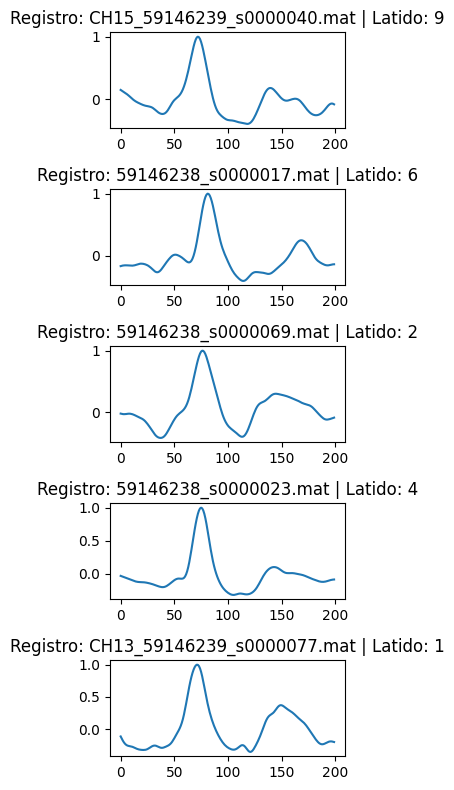

In [5]:
# ============================
# --- FILTRADO DE SEÑALES ---
# ============================

FS = 198.46762  # Frecuencia de muestreo fija

def butter_bandpass_filter(data, lowcut=0.5, highcut=20, fs=FS, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

def filtrar_icg(icg_raw, fs=FS):
    icg_bandpassed = butter_bandpass_filter(icg_raw, 0.5, 20, fs)
    icg_filtered = savgol_filter(icg_bandpassed, window_length=25, polyorder=3)
    return icg_filtered

# ============================
# --- PROCESAMIENTO DE DATOS ---
# ============================

def leer_measures(filepath):
    if filepath.endswith('.mat'):
        data = sio.loadmat(filepath)
        return data['measure']
    return None

def procesar_archivo(filepath):
    try:
        measures = leer_measures(filepath)
        if measures is None:
            return []

        ecg = measures[0, 1]['data'][0, 0].squeeze()
        r_peaks = (measures[2, 1]['data'][0, 0].flatten() * FS).astype(int)

        # Derivar la impedancia para obtener ICG
        impedance_data = measures[1, 1]['data'][0, 0]
        #obtenemos icg como derivada de la impedancia
        icg_raw = np.gradient(impedance_data.flatten())
        icg_filtrada = filtrar_icg(icg_raw)

        segmentos = []
        for i, r in enumerate(r_peaks):
            if r - 50 >= 0 and r + 150 < len(icg_filtrada):
                segmento = icg_filtrada[r - 50: r + 150]
                # Normalizar en amplitud (estandarizar)
                max_amplitude = np.max(np.abs(segmento))
                if max_amplitude == 0:
                    max_amplitude = 1
                segment_norm = segmento / max_amplitude

                segmentos.append({
                    'registro': os.path.basename(filepath),
                    'latido': i,
                    'icg_segment': segment_norm
                })
        return segmentos

    except Exception as e:
        print(f"Error en archivo {filepath}: {e}")
        return []

# ============================
# --- LOOP Y EXPORTACIÓN ---
# ============================

drive.mount('/content/drive')

root_dir = '/content/drive/MyDrive/HeartCycle'
carpetas = ['59146237', '59146238', '59146239']
resultados = []

for carpeta in carpetas:
    folder_path = os.path.join(root_dir, carpeta)
    for archivo in tqdm(os.listdir(folder_path), desc=f"Procesando {carpeta}"):
        if archivo.endswith('.mat'):
            full_path = os.path.join(folder_path, archivo)
            resultados.extend(procesar_archivo(full_path))

# Crear DataFrame y guardar
df_segments = pd.DataFrame(resultados)
df_segments.to_csv('/content/icg_segmentos_filtrados.csv', index=False)
print(" Segmentos guardados en CSV.")

# ============================
# --- VISUALIZACIÓN ---
# ============================

# Visualiza 5 segmentos aleatorios
if not df_segments.empty:
    print("\n Graficando 5 segmentos ICG aleatorios...")
    muestras = df_segments.sample(n=5, random_state=42)

    plt.figure(figsize=(3, 8))
    for idx, row in enumerate(muestras.itertuples()):
        plt.subplot(5, 1, idx + 1)
        plt.plot(row.icg_segment)
        plt.title(f"Registro: {row.registro} | Latido: {row.latido}")
        plt.tight_layout()
    plt.show()


Next, we want to create a second dataset which, unlike the previous one, will include all subcomplexes except for subcomplex u. This is done so that, when performing clustering later, those u subcomplexes do not introduce noise, as they do not provide any useful information about the ICG. For this purpose a Random Forest Algorithm is applied.

Label(value='Introduce etiquetas para los segmentos mostrados:')

Text(value='', description='Etiquetas: ', placeholder='Escribe las etiquetas aquí')

Button(description='Enviar Etiquetas', style=ButtonStyle())

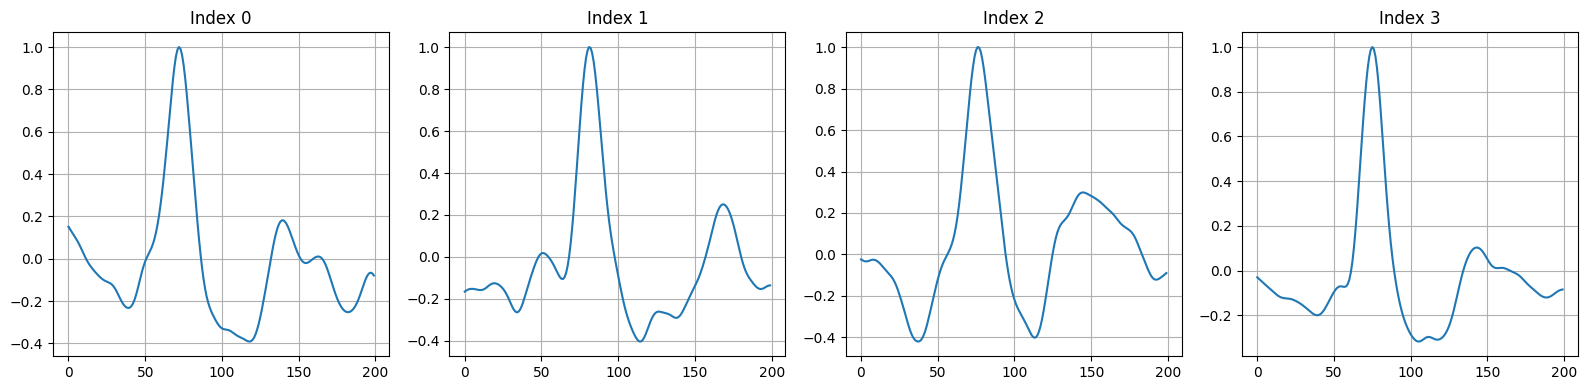

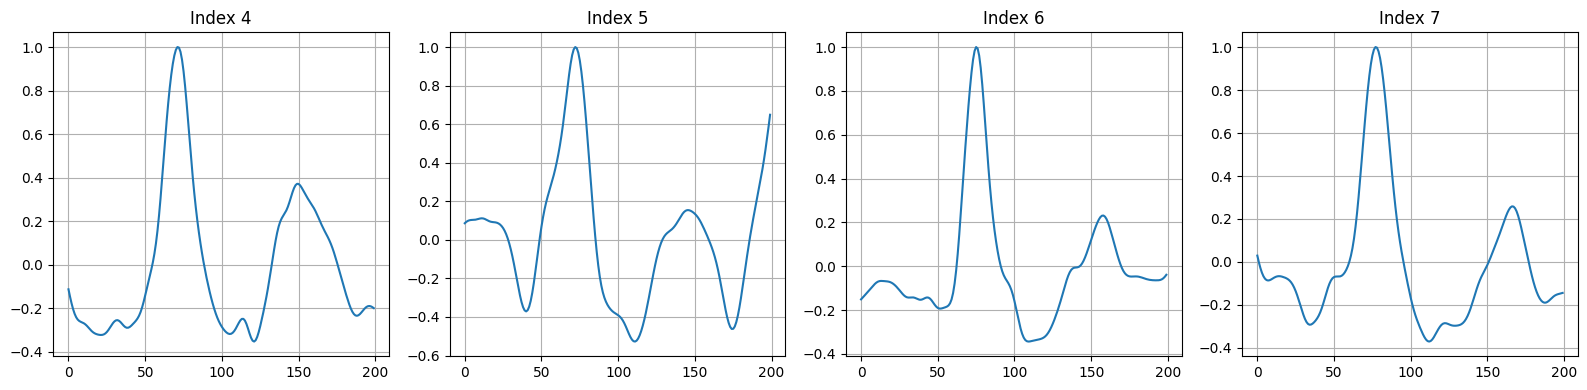

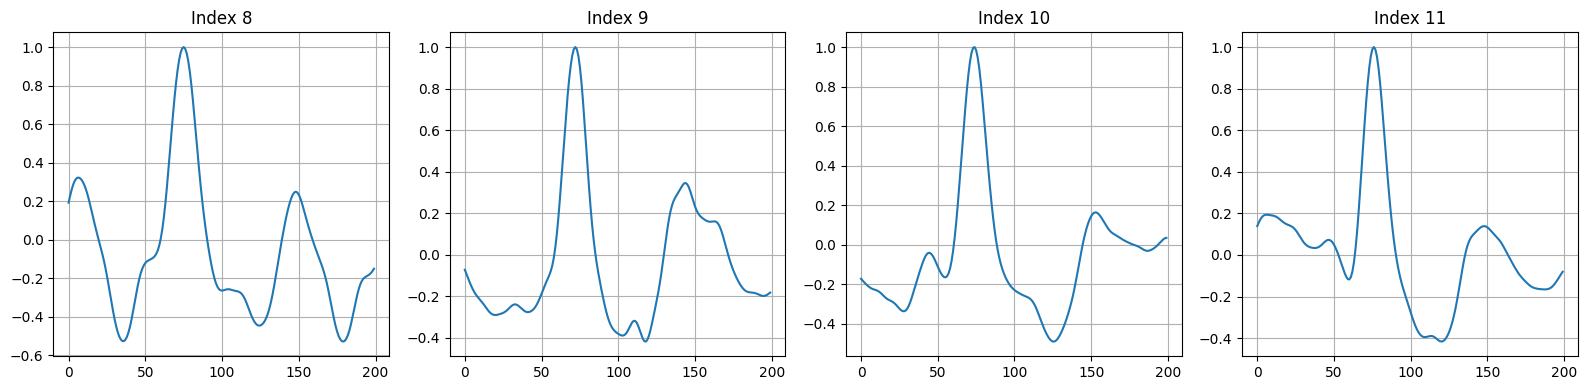

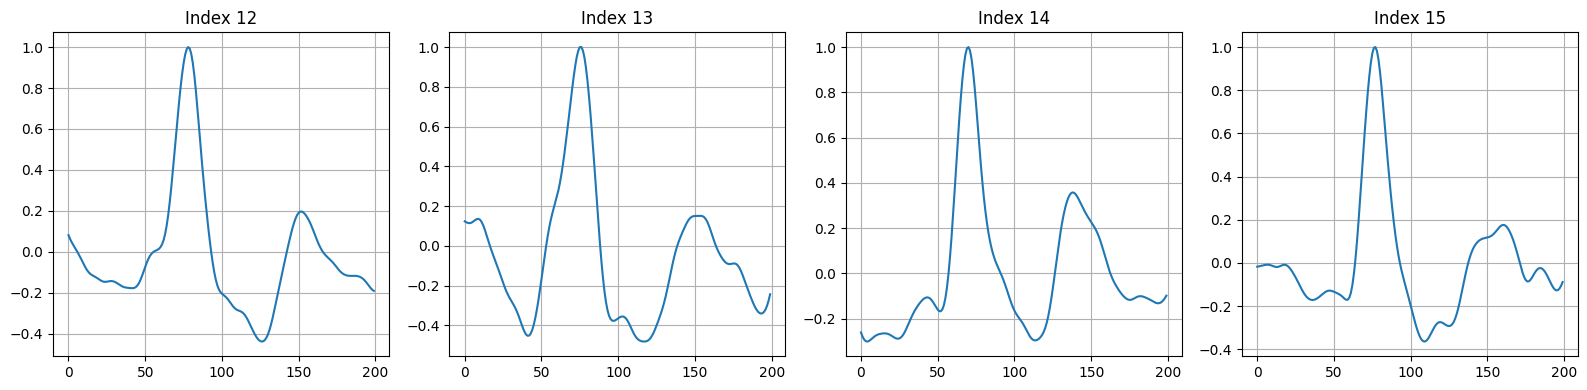

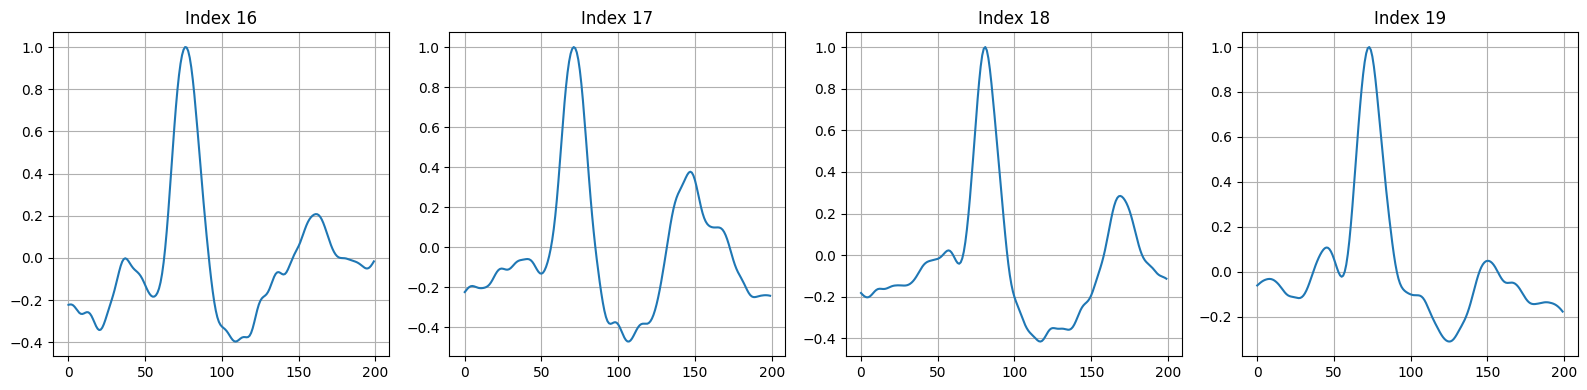

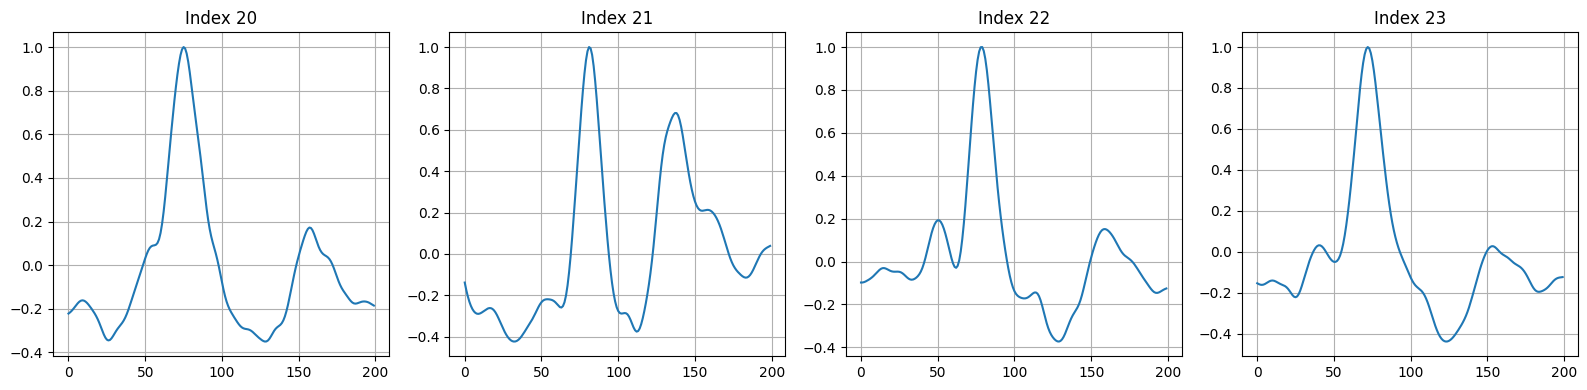

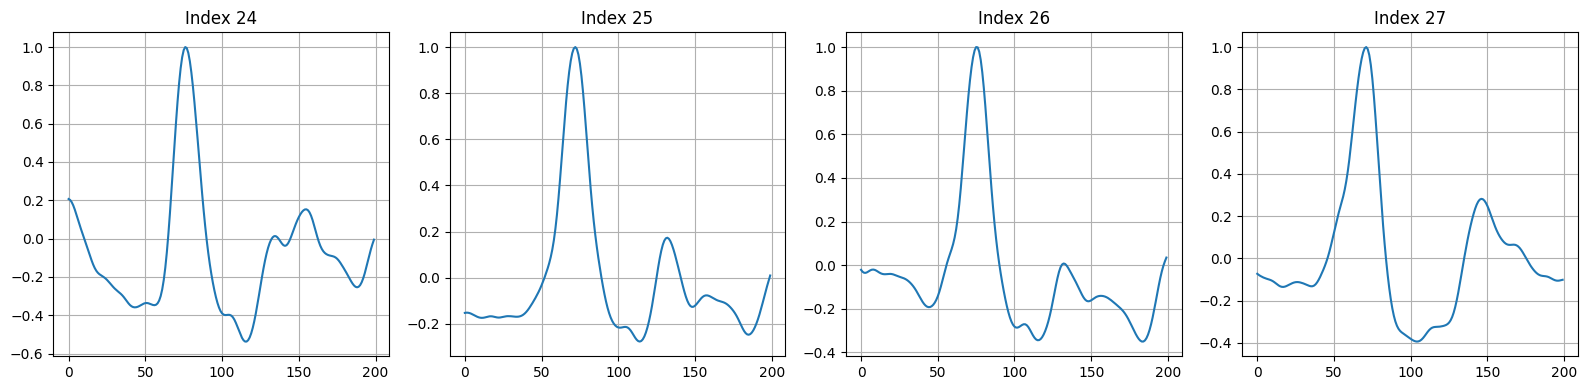

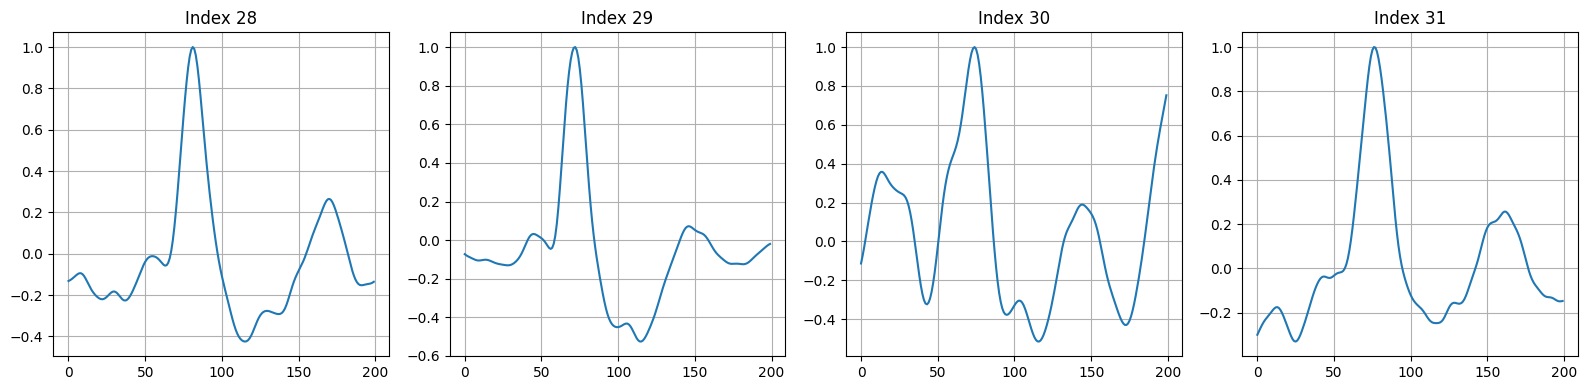

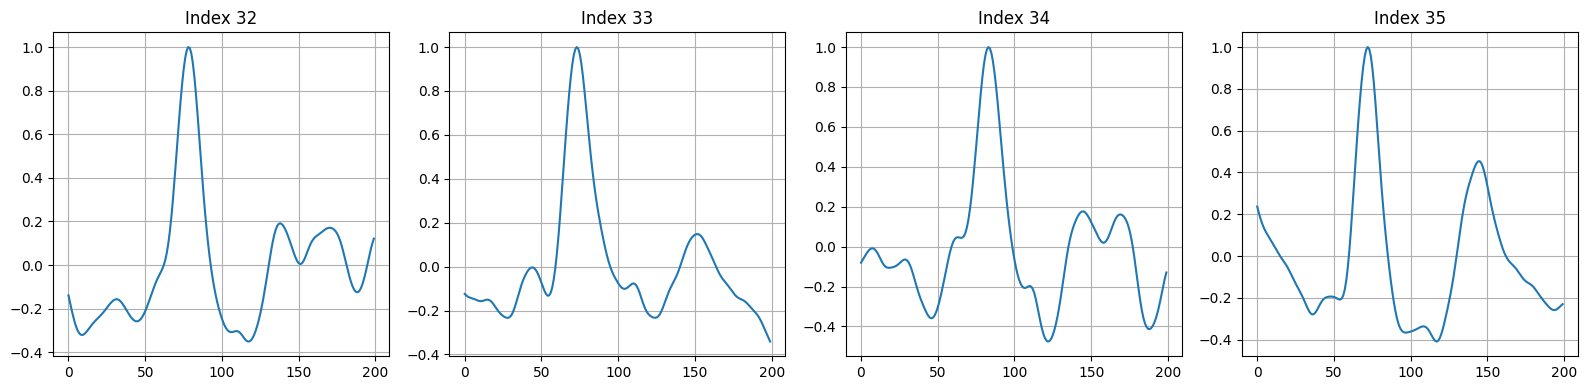

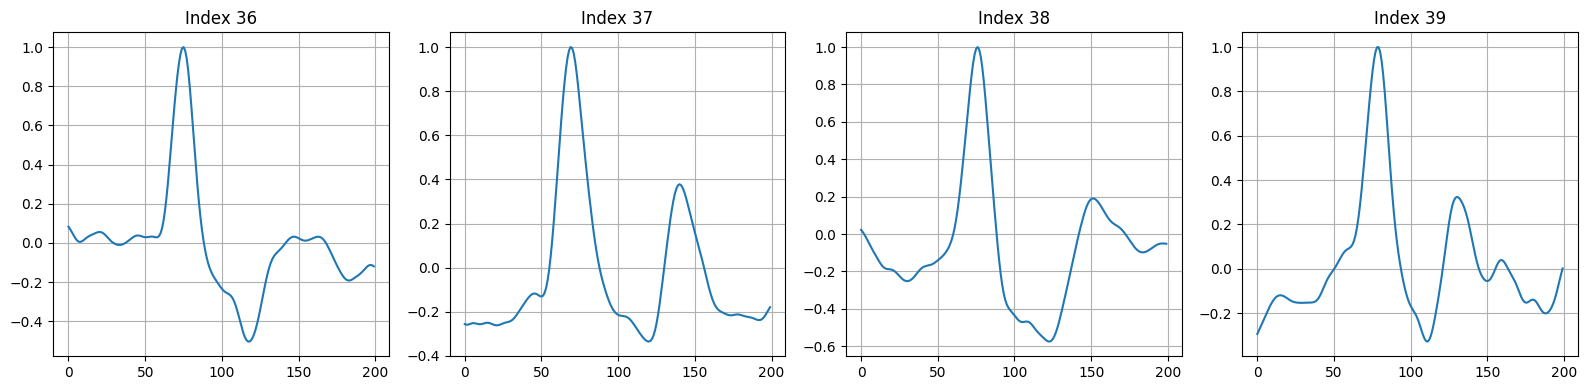

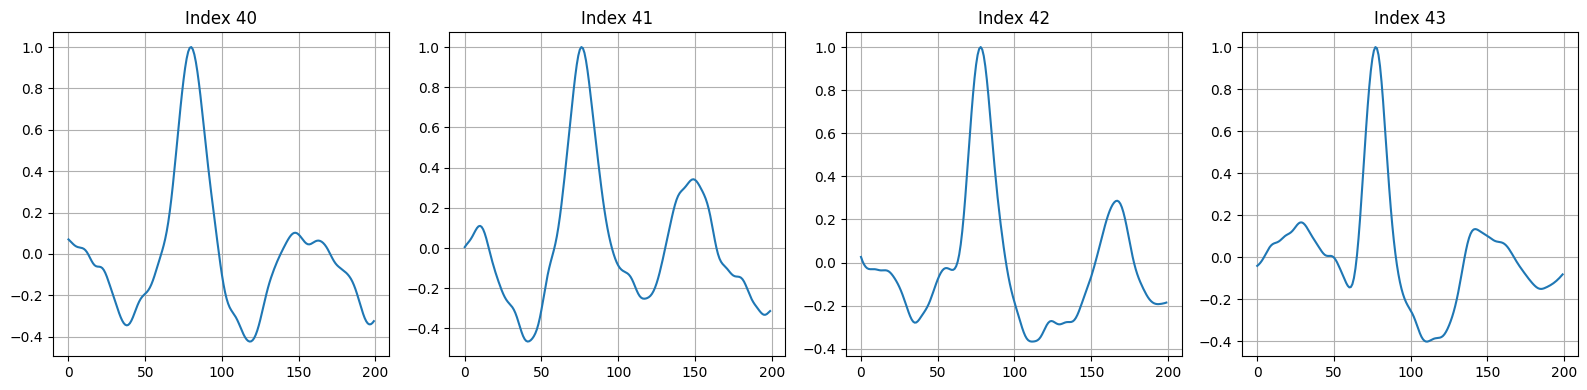

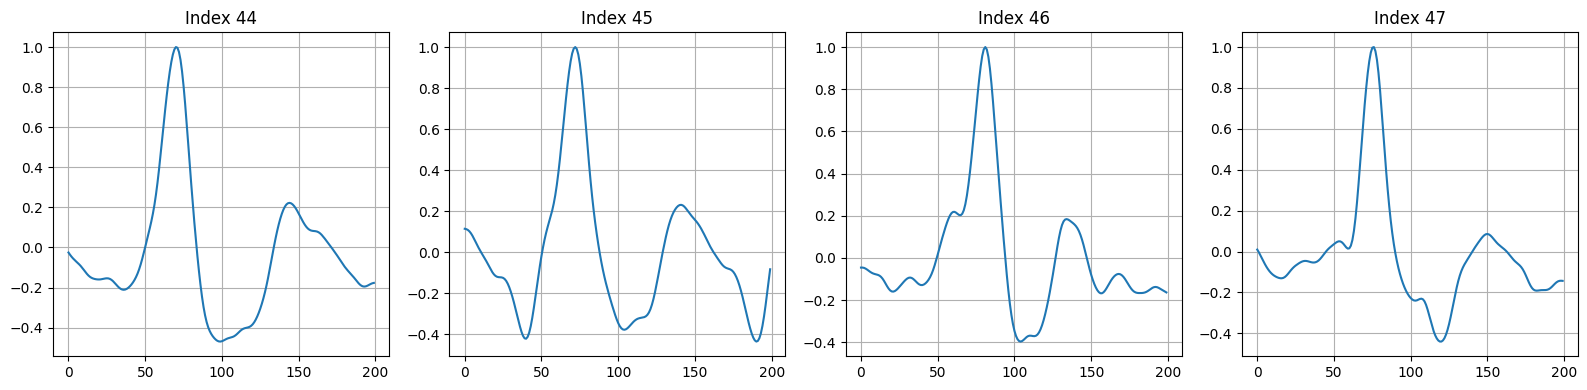

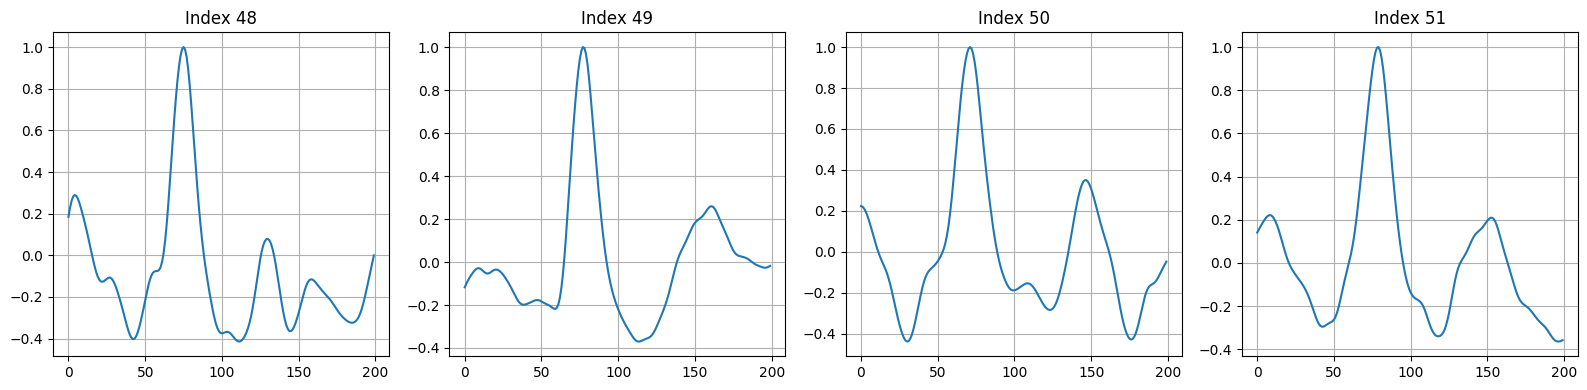

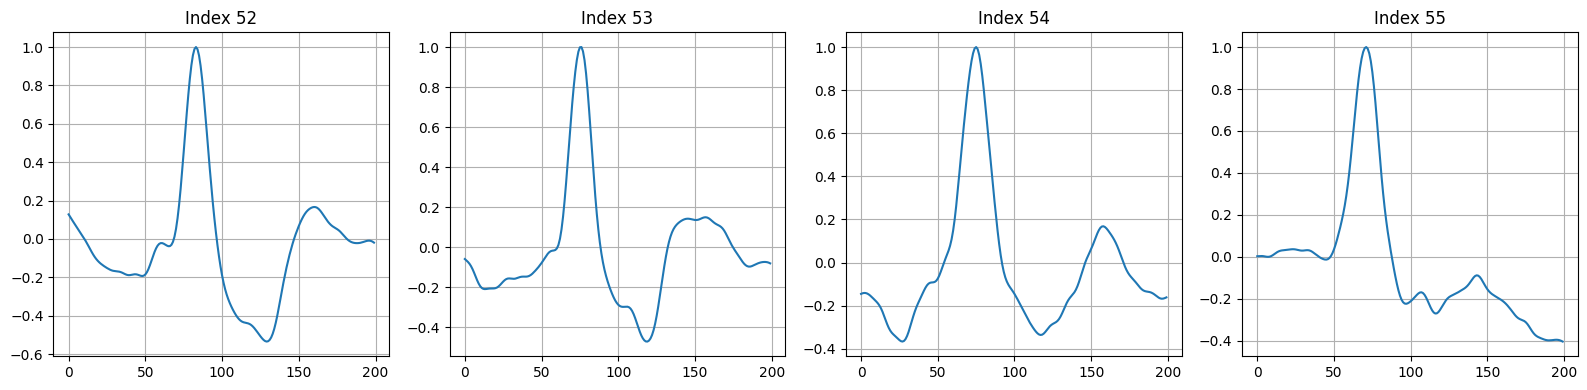

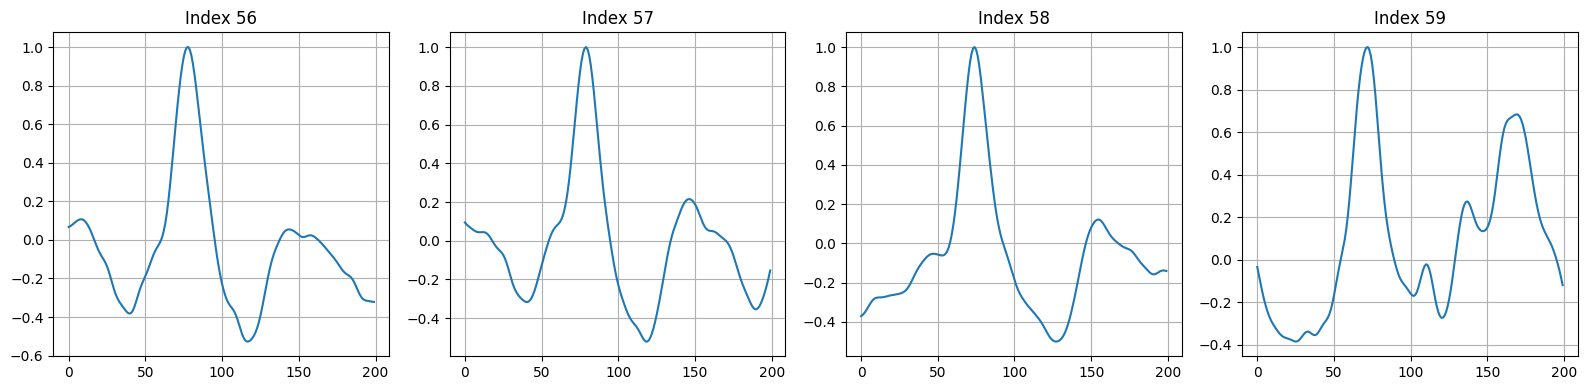

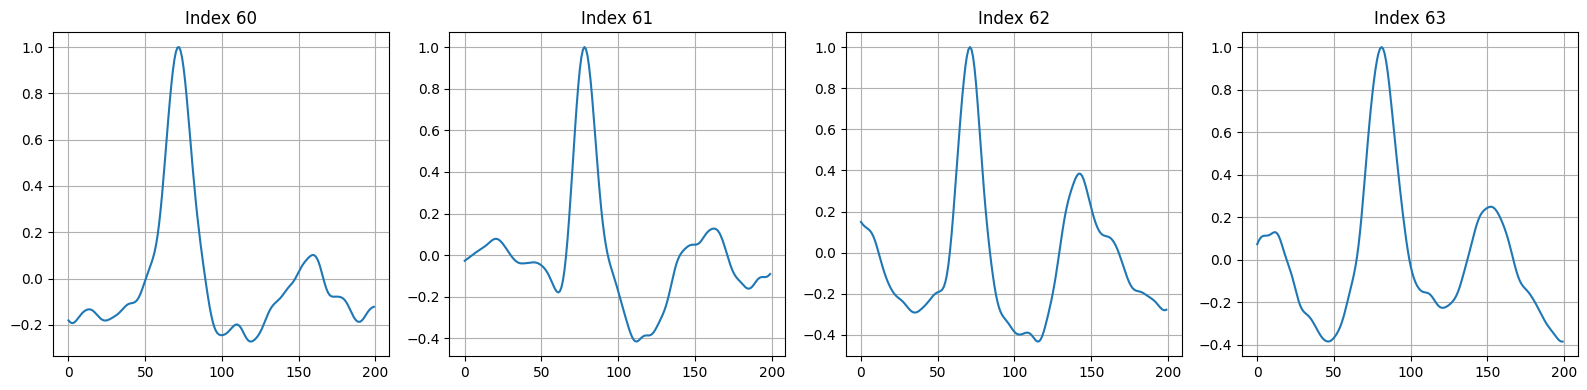

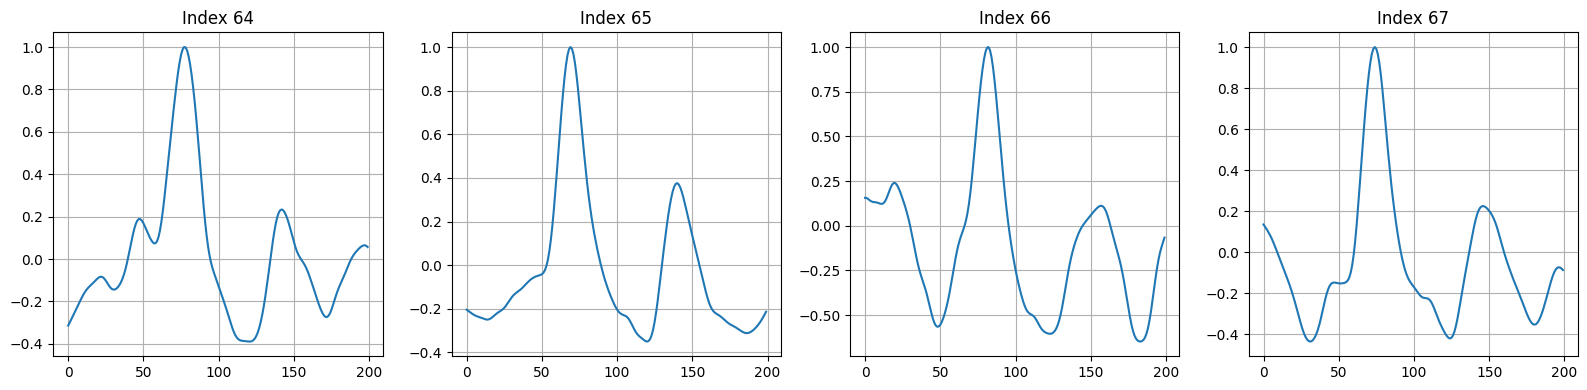

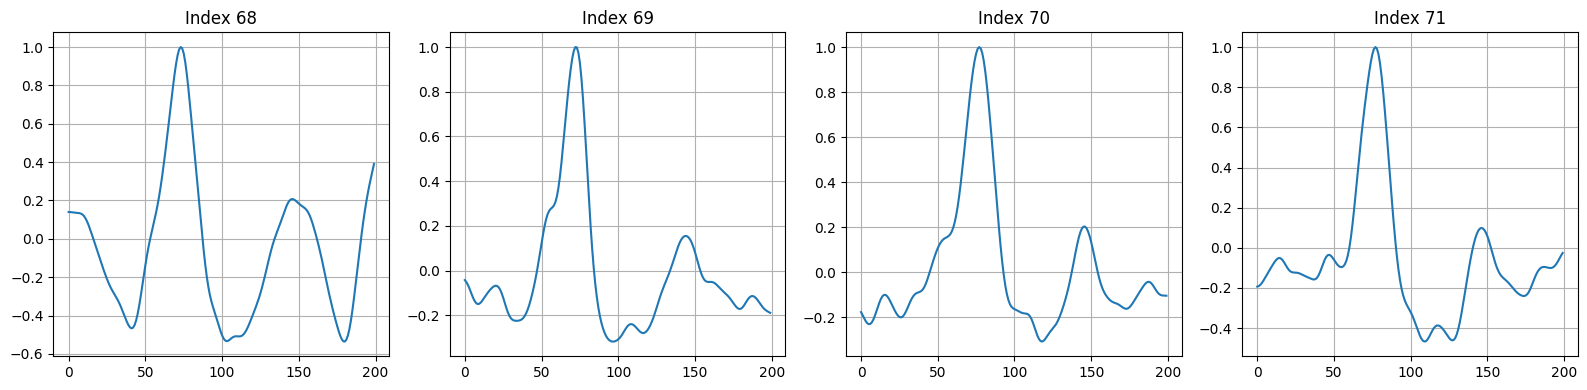

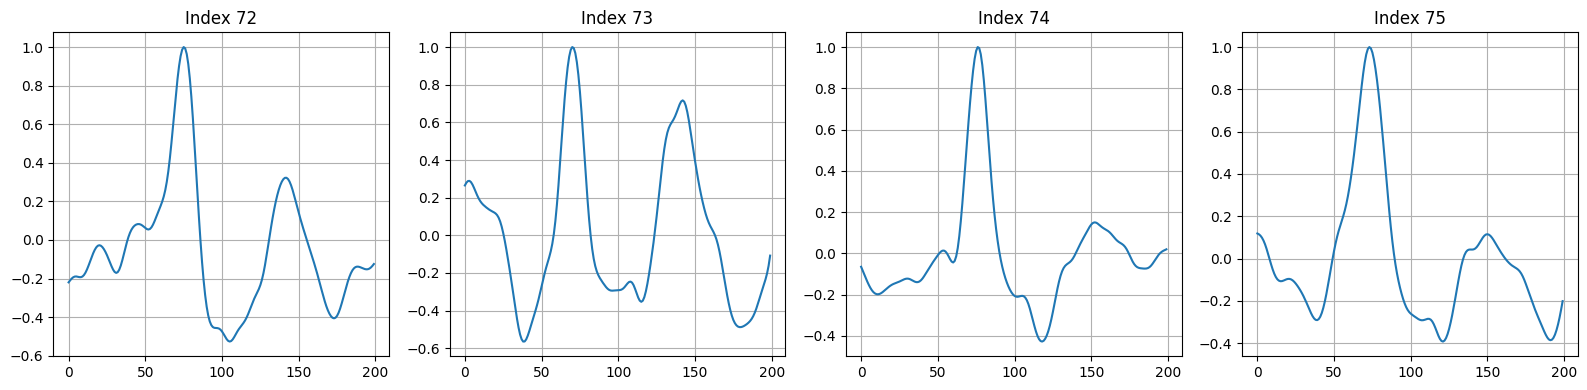

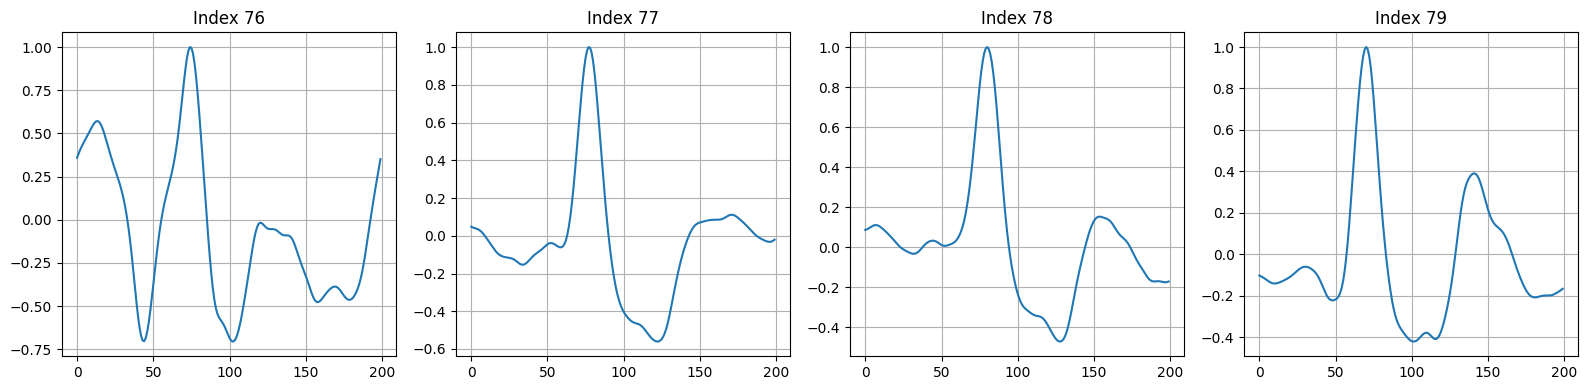

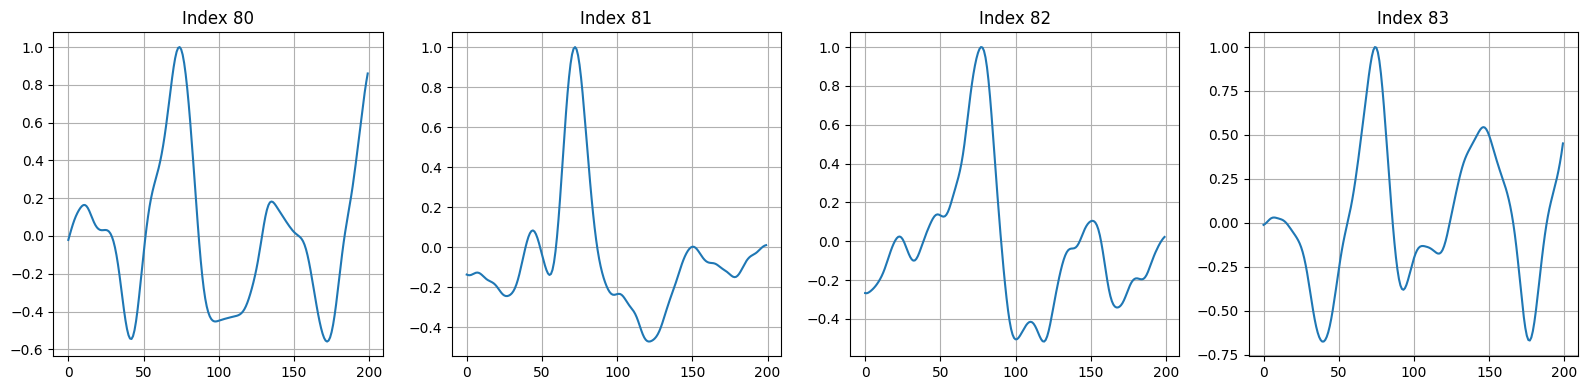

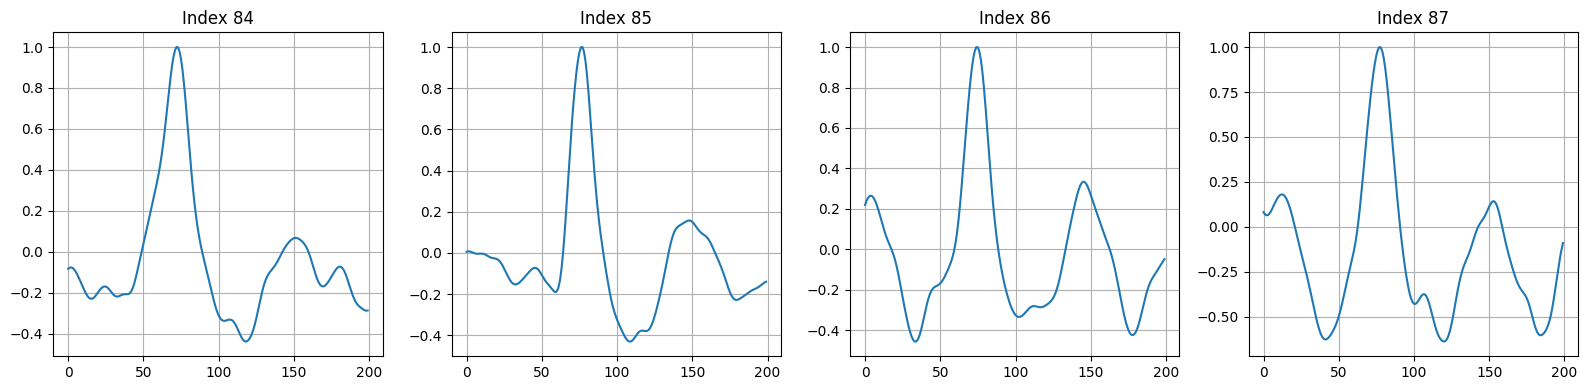

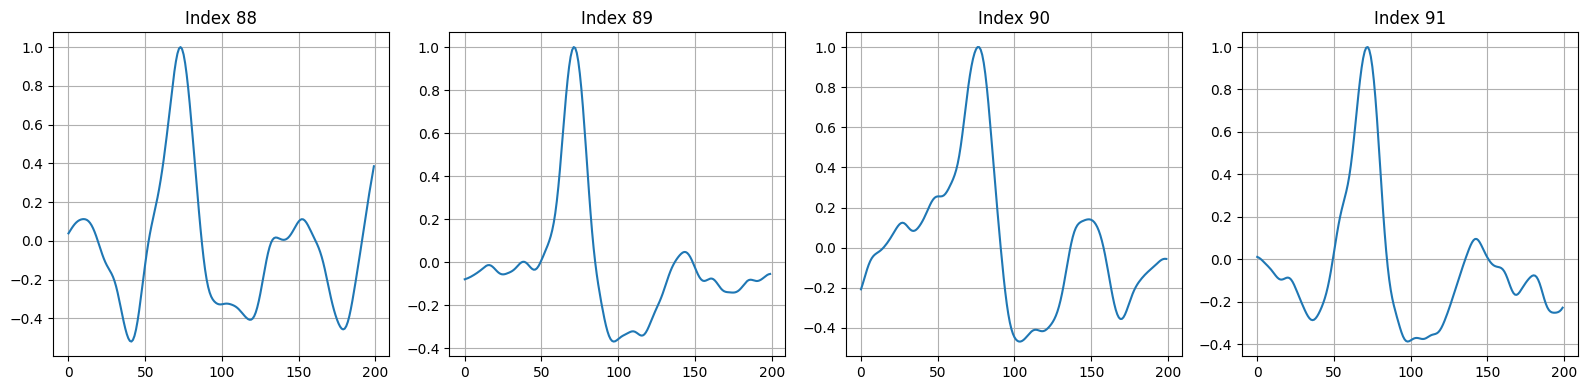

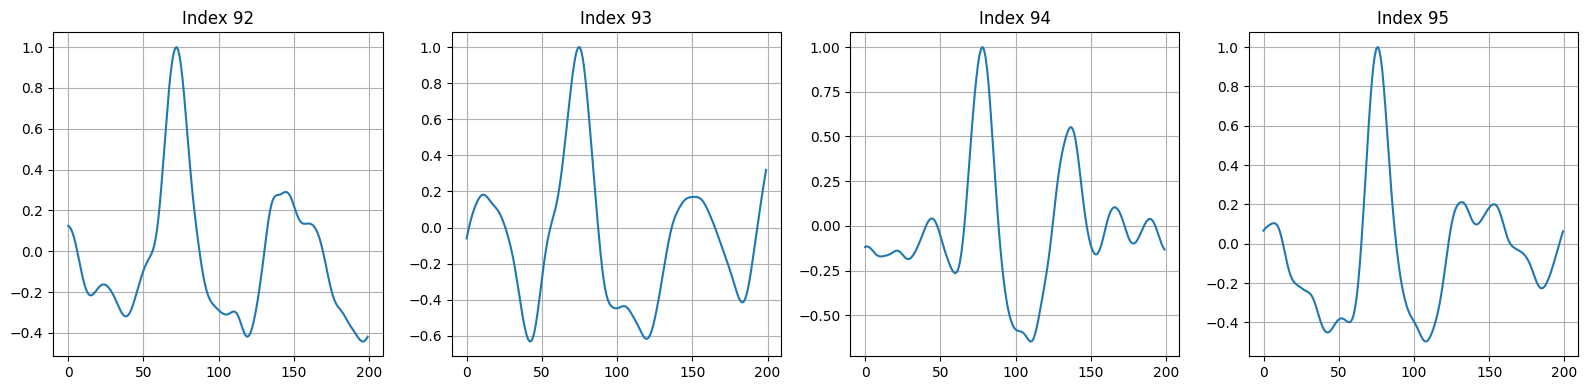

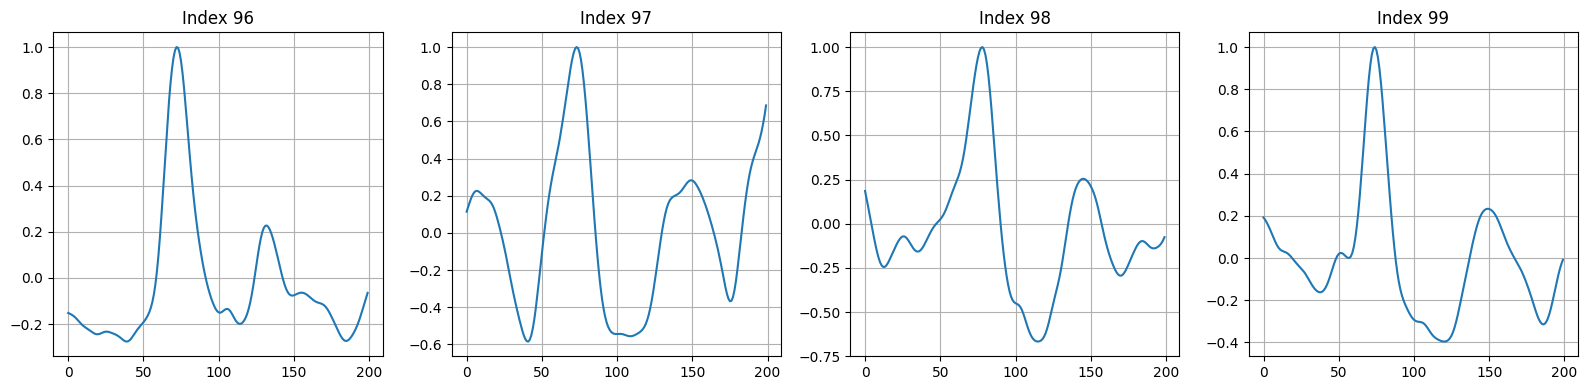

Etiquetado completado.
Segmentos guardados en CSV.


In [6]:
# Número de muestras para etiquetar manualmente
num_samples = 100
batch_size = 4    # Cuántos gráficos mostramos a la vez

# Seleccionar segmentos aleatorios
random.seed()
sampled_df = df_segments.sample(n=num_samples, random_state=42).reset_index(drop=True)

# Lista para almacenar las etiquetas
labels = []

# Función que se usará para actualizar las etiquetas
def on_button_click(b):
    global current_batch_index, labels, sampled_df, batch

    # Obtener las etiquetas del input y dividirlas
    batch_labels = text_input.value.upper().split()

    if len(batch_labels) == len(batch) and all(l in ['V', 'U'] for l in batch_labels):
        # Si las etiquetas son correctas, añadirlas al DataFrame
        labels.extend(batch_labels)
        current_batch_index += 1

        # Verificar si aún hay más lotes para etiquetar
        if current_batch_index < num_samples // batch_size:
            # Actualizar el gráfico y la solicitud de etiquetas
            update_batch()
        else:
            print("Etiquetado completado.")
            # Guardar el DataFrame con las etiquetas
            sampled_df['Label'] = labels
            sampled_df.to_csv("icg_labeled_V_U.csv", index=False)
            print("Segmentos guardados en CSV.")
            button.disabled = True
    else:
        print("Error: Debes introducir exactamente una etiqueta V o U por cada segmento mostrado.")

# Función para actualizar el gráfico y mostrar los nuevos segmentos a etiquetar
def update_batch():
    global batch, text_input, current_batch_index, label_request

    # Crear subgráficos para mostrar los segmentos
    batch_start = current_batch_index * batch_size
    batch_end = min(batch_start + batch_size, num_samples)
    batch = sampled_df.iloc[batch_start:batch_end]

    fig, axs = plt.subplots(1, len(batch), figsize=(16, 4))

    if len(batch) == 1:
        axs = [axs]  # Para que axs sea siempre iterable

    for ax, (_, row) in zip(axs, batch.iterrows()):
        segment = row['icg_segment']
        ax.plot(segment)
        ax.set_title(f"Index {row.name}")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

    # Actualizar el texto de la solicitud
    label_request.value = f"Introduce {len(batch)} etiquetas separadas por espacio (V para válido, U para inválido):"

# Inicializar el índice del lote actual
current_batch_index = 0

# Crear el cuadro de texto para introducir las etiquetas
text_input = widgets.Text(
    placeholder='Escribe las etiquetas aquí',
    description='Etiquetas: ',
    disabled=False
)

# Crear el botón para enviar las etiquetas
button = widgets.Button(description="Enviar Etiquetas")
button.on_click(on_button_click)

# Crear el texto de la solicitud
label_request = widgets.Label(value="Introduce etiquetas para los segmentos mostrados:")

# Mostrar la interfaz en Colab
display(label_request)
display(text_input)
display(button)

# Actualizar la visualización con los primeros segmentos
update_batch()


In [7]:
# Función para extraer características simples de cada segmento
def extract_features(segments):
    features = []
    for segment in segments:
        mean = np.mean(segment)
        std = np.std(segment)
        max_val = np.max(segment)
        min_val = np.min(segment)
        skewness = skew(segment)
        kurt = kurtosis(segment)
        features.append([mean, std, max_val, min_val, skewness, kurt])
    return np.array(features)

# Extraer características del df que yo he clasificado como U o V
X = extract_features(sampled_df['icg_segment'])
y = sampled_df['Label'].apply(lambda x: 1 if x == 'V' else 0)  # Convertir 'V' a 1 y 'U' a 0

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar el modelo Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Evaluar el modelo
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        30

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:
# Asumimos que df_segments contiene todos los segmentos restantes
#Extraemos características de todos los segmentos del df
X_all = extract_features(df_segments['icg_segment'])

# Predecir etiquetas para el resto de los segmentos
y_all_pred = rf.predict(X_all)

# Convertir las predicciones de 0 y 1 de nuevo a 'V' y 'U'
df_segments['Predicted_Label'] = ['V' if label == 1 else 'U' for label in y_all_pred]

# Guardar el DataFrame con las predicciones
df_segments.to_csv("icg_segments_with_predictions.csv", index=False)


U and V distribution

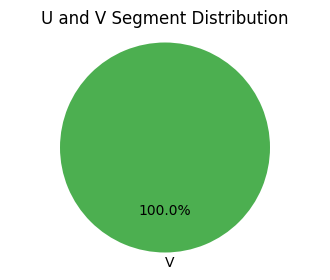

In [9]:
# Contar la cantidad de segmentos de tipo V y U
label_counts = df_segments['Predicted_Label'].value_counts()

# Graficar distribución de segmentos V y U
plt.figure(figsize=(4, 3))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#FF6347'])
plt.title("U and V Segment Distribution")
plt.axis('equal')  # Asegura que el gráfico sea un círculo
plt.show()


Here the code shows a plot of a random U segment that has been eliminated. As this DB has really low number of U segments, this code may show an error as there are not U segments to plot.

In [10]:
# Filtrar los segmentos clasificados como 'U'
u_segments = df_segments[df_segments['Predicted_Label'] == 'U']

# Seleccionar un número aleatorio de segmentos 'U' para visualizar
num_segments_to_show = 1
random_u_segments = u_segments.sample(n=num_segments_to_show, random_state=42)

# Graficar los segmentos 'U' seleccionados
plt.figure(figsize=(22, 4))

for i, (_, row) in enumerate(random_u_segments.iterrows()):
    plt.subplot(1, num_segments_to_show, i + 1)
    plt.plot(row['icg_segment'])
    plt.title(f"Segment U {i+1}")
    plt.grid(True)

plt.tight_layout()
plt.show()


ValueError: a must be greater than 0 unless no samples are taken

Save V segments

In [11]:
# Filtrar los segmentos clasificados como 'V' (válidos)
v_segments = df_segments[df_segments['Predicted_Label'] == 'V']
#A partir de ahora he de emplear esto apra referirme a los segmentos de icg filtrados (sin los subcomplejos u)

# Guardar los segmentos V en un nuevo archivo CSV
v_segments.to_csv("icg_segments_validos.csv", index=False)

print("Archivo 'icg_segments_validos.csv' guardado exitosamente.")

Archivo 'icg_segments_validos.csv' guardado exitosamente.


###Clustering Algorithms

Segment ICG segments in order to apply clustering only in the variable part

[200]


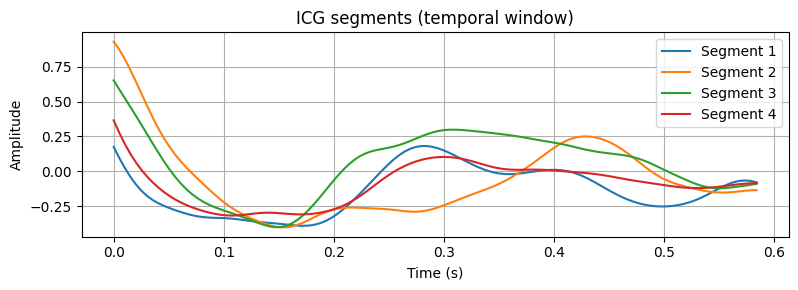

(1657, 116)


In [12]:
# Verifica que todos los segmentos tienen la misma longitud
segment_lengths = v_segments['icg_segment'].apply(len)
print(segment_lengths.unique())

# Recorta los segmentos desde el 42% hacia adelante
v_segments['Segment_partial'] = v_segments['icg_segment'].apply(lambda x: x[int(0.42 * len(x)):])

# Seleccionar 4 segmentos aleatorios de la columna 'Segment_partial'
sampled_segments = v_segments['Segment_partial'].sample(4, random_state=42).reset_index(drop=True)

# Crear la figura para visualizar los segmentos en función del tiempo
plt.figure(figsize=(8, 3))

for i, segment in enumerate(sampled_segments):
    segment = np.array(segment)
    time_vector = np.linspace(0, len(segment) / FS, len(segment))  # Tiempo en segundos
    plt.plot(time_vector, segment, label=f'Segment {i+1}')

plt.title('ICG segments (temporal window)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Convertir todos los segmentos parciales a matriz numpy para clustering
X = np.stack(v_segments['Segment_partial'].values)
print(X.shape)  # (n_segmentos, longitud_segmento)


###Delineation Algorithm for each characteristic Point:

####C point detection:

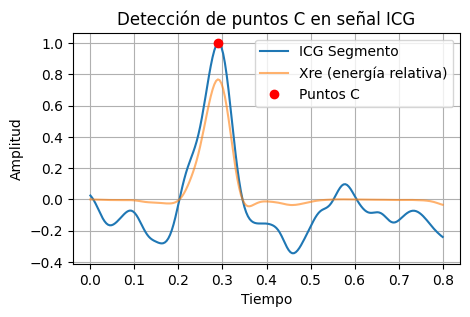

In [13]:
def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)

    for n in range(len(signal)):
        i1 = max(0, n - long_len // 2)
        i2 = min(len(signal), n + long_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)

        j1 = max(0, n - short_len // 2)
        j2 = min(len(signal), n + short_len // 2)
        short_energy = np.sum(signal[j1:j2] ** 2)

        if long_energy != 0:
            c = short_energy / long_energy
            Xre[n] = signal[n] * c
    return Xre

def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)

    # Thresholds
    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 and sorted_peaks[-2] > np.mean(Xre) else sorted_peaks[-1]

    Thr_max = 0.2 * maxval
    Thr_min = 0.02 * maxval

    C_peaks = []
    active = False
    start_idx = 0

    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active = True
            start_idx = i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if len(C_peaks) == 0 or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    # Filtrar según intervalos C-C
    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            if len(prev_cc) == 5:
                avg_cc = np.mean(prev_cc)
                if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                    final_C_peaks.append(p)
            else:
                final_C_peaks.append(p)

    return np.array(final_C_peaks), Xre

#Cogemos un segmento de icg cuya etiqueta sea V
icg_segment = v_segments['icg_segment'].iloc[100]
fs=250
C_peaks, Xre = detect_C_peaks(icg_segment, fs)

#Definimos el tiempo para representar en función del tiempo en lugar de muestras
tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))

# Representación
plt.figure(figsize=(5, 3))
plt.plot(tiempo, icg_segment, label="ICG Segmento")
plt.plot(tiempo, Xre, label="Xre (energía relativa)", alpha=0.6)
plt.plot(tiempo[C_peaks], icg_segment[C_peaks], 'ro', label="Puntos C")
plt.legend()
plt.title("Detección de puntos C en señal ICG")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


####B point detection:

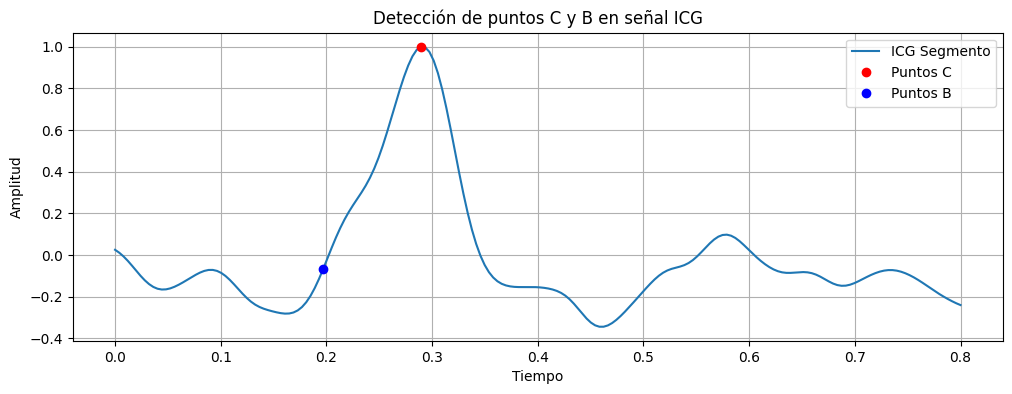

In [14]:
def find_B_point(icg_segment, Cpos, fs, Afrac=0.2, Bslope1=0.11, Bslope2=0.08):
    # Paso 1: calcular límites de la ventana de búsqueda
    BlimL = max(0, int(Cpos - 0.09 * fs))  # 80 ms antes del C
    C_amp = icg_segment[Cpos]

    # Buscar BlimR: el índice más cercano a la izquierda donde la señal < Afrac * C_amp
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * C_amp:
            BlimR = i
            break
    else:
        BlimR = BlimL  # Si no se encuentra, que sea igual al límite inferior

    # Derivada primera (pendiente) de la señal
    slope = np.gradient(icg_segment)

    # Paso 2: búsqueda con Bslope1
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and (icg_segment[i] < icg_segment[i-1])) or abs(slope[i]) > Bslope1:
            return i

    # Paso 3: búsqueda con Bslope2
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i

    # Paso 4: si no se encuentra, retornar el mínimo de la ventana
    search_region = icg_segment[BlimL:BlimR+1]
    return BlimL + np.argmin(search_region)

B_points = []
for Cpos in C_peaks:
    B_idx = find_B_point(icg_segment, Cpos, fs)
    B_points.append(B_idx)

# Visualización
plt.figure(figsize=(12, 4))
plt.plot(tiempo, icg_segment, label="ICG Segmento")
plt.plot(tiempo[C_peaks], icg_segment[C_peaks], 'ro', label="Puntos C")
plt.plot(tiempo[B_points], icg_segment[B_points], 'bo', label="Puntos B")
plt.legend()
plt.title("Detección de puntos C y B en señal ICG")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


####X point detection:

<ipython-input-15-62484b317c75>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start = max(int(C_index + CXmin_samp), 0)
<ipython-input-15-62484b317c75>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)


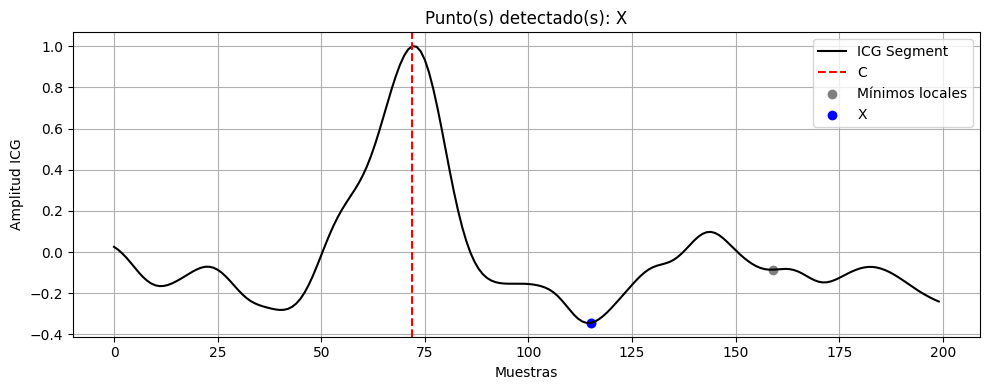

{'caso': 'X', 'X': np.int64(115)}


In [15]:
def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):

    # 1. Definir ventana temporal (0.1s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        # Tomar los dos primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]

        # Comparar amplitudes
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset
        idx = min_indices[0]

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) >= 3:
        # Tomar los tres primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]
        X3_idx = min_indices[2]

        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset
        idx = min_indices[0]

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}

        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}

        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # 6. Graficar resultados
    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(icg_segment, label='ICG Segment', color='black')
        plt.axvline(x=C_index, color='red', linestyle='--', label='C')

        # Ajustar índices locales a posición original
        min_plot_idx = min_indices + start
        plt.scatter(min_plot_idx, icg_segment[min_plot_idx], color='gray', label='Mínimos locales')

        if resultado["caso"] == "X":
            plt.scatter(resultado["X"] + start, icg_segment[resultado["X"] + start], color='blue', label='X')
        elif resultado["caso"] == "X1":
            plt.scatter(resultado["X1"] + start, icg_segment[resultado["X1"] + start], color='orange', label='X1')
        elif resultado["caso"] == "X1_X2":
                plt.scatter(resultado["X1"] + start, icg_segment[resultado["X1"] + start],
                color='orange', label='X1')
                plt.scatter(resultado["X2"] + start, icg_segment[resultado["X2"] + start],
                color='blue', label='X2')
        plt.title(f"Punto(s) detectado(s): {resultado['caso']}")
        plt.xlabel("Muestras")
        plt.ylabel("Amplitud ICG")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


    # Ajustar índices al segmento original
    if resultado["caso"] == "X":
        resultado["X"] = resultado["X"] + start
    elif resultado["caso"] == "X1":
        resultado["X1"] = resultado["X1"] + start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] = resultado["X1"] + start
        resultado["X2"] = resultado["X2"] + start

    return resultado

segmento = v_segments['icg_segment'].iloc[100]
fs = 250
C_index, _ = detect_C_peaks(segmento, fs)

resultado = detectar_punto_X(segmento, C_index, fs, plot=True)
print(resultado)

####O point detection:

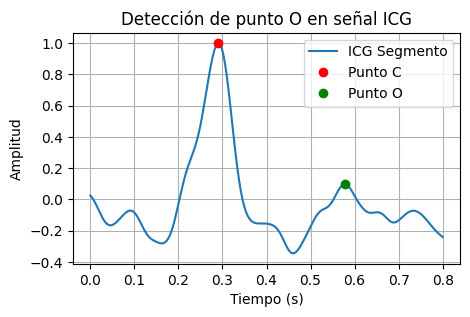

In [16]:
def detect_O_point(segment, C_index, fs):

    # Zona de búsqueda: 0.1s a 0.5s después del punto C
    start_search = C_index + int(0.2 * fs)  # 0.2 segundos después de C
    end_search = C_index + int(0.5 * fs)    # 0.5 segundos después de C

    # Asegurar que los índices no se salgan del rango
    end_search = min(end_search, len(segment))

    # Extraer la región de búsqueda
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None  # No hay espacio para buscar

    # Buscar máximos locales
    peaks, _ = signal.find_peaks(search_region)

    if len(peaks) == 0:
        return None  # No se encontró ningún máximo local

    # Elegir el pico de mayor amplitud (el más alto)
    peak_amplitudes = search_region[peaks]
    max_peak_idx = peaks[np.argmax(peak_amplitudes)]

    # Convertir índice relativo a índice absoluto en el segmento
    O_index = start_search + max_peak_idx
    return O_index

# Suponiendo que ya tienes detectados los puntos C en los segmentos
# Si se ha detectado al menos un punto C
if len(C_peaks) > 0:
    C_idx = C_peaks[0]  # Suponiendo un solo punto C por segmento
    O_idx = detect_O_point(icg_segment, C_idx, fs)

    # Representación
    tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))
    plt.figure(figsize=(5, 3))
    plt.plot(tiempo, icg_segment, label="ICG Segmento")
    plt.plot(tiempo[C_idx], icg_segment[C_idx], 'ro', label="Punto C")
    if O_idx is not None:
        plt.plot(tiempo[O_idx], icg_segment[O_idx], 'go', label="Punto O")
    plt.legend()
    plt.title("Detección de punto O en señal ICG")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()


####Z point detection:

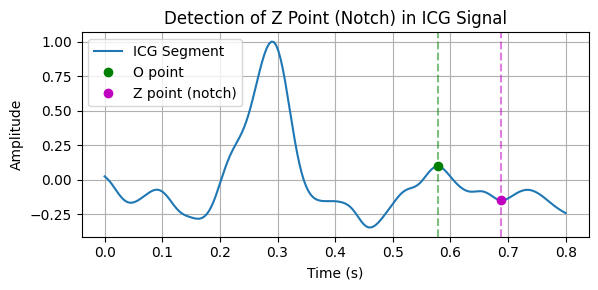

In [17]:
def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the deepest local minimum (notch)
    valley_amplitudes = search_region[peaks]
    min_peak_idx = peaks[np.argmin(valley_amplitudes)]

    # Convert to absolute index
    Z_index = start_search + min_peak_idx
    return Z_index

# Example of usage (assuming icg_segment, fs, and O_idx are defined)
Z_idx = detect_Z_point(icg_segment, O_idx, fs)

# Time vector for plotting
tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))

# Plotting the ICG signal with O and Z points
plt.figure(figsize=(6, 3))
plt.plot(tiempo, icg_segment, label="ICG Segment")
plt.plot(tiempo[O_idx], icg_segment[O_idx], 'go', label="O point")
if Z_idx is not None:
    plt.plot(tiempo[Z_idx], icg_segment[Z_idx], 'mo', label="Z point (notch)")
    plt.axvline(tiempo[Z_idx], color='m', linestyle='--', alpha=0.5)
plt.axvline(tiempo[O_idx], color='g', linestyle='--', alpha=0.5)
plt.title("Detection of Z Point (Notch) in ICG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


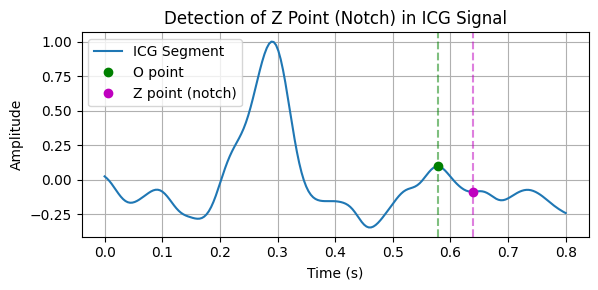

In [18]:
def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the first local minimum
    Z_index = start_search + peaks[0]
    return Z_index

# Example of usage (assuming icg_segment, fs, and O_idx are defined)
Z_idx = detect_Z_point(icg_segment, O_idx, fs)

# Time vector for plotting
tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))

# Plotting the ICG signal with O and Z points
plt.figure(figsize=(6, 3))
plt.plot(tiempo, icg_segment, label="ICG Segment")
plt.plot(tiempo[O_idx], icg_segment[O_idx], 'go', label="O point")
if Z_idx is not None:
    plt.plot(tiempo[Z_idx], icg_segment[Z_idx], 'mo', label="Z point (notch)")
    plt.axvline(tiempo[Z_idx], color='m', linestyle='--', alpha=0.5)
plt.axvline(tiempo[O_idx], color='g', linestyle='--', alpha=0.5)
plt.title("Detection of Z Point (Notch) in ICG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


####Y point detection:

<ipython-input-15-62484b317c75>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start = max(int(C_index + CXmin_samp), 0)
<ipython-input-15-62484b317c75>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)


Usando X_idx en detectar_punto_Y: 110
No se detectaron mínimos locales entre X y O.


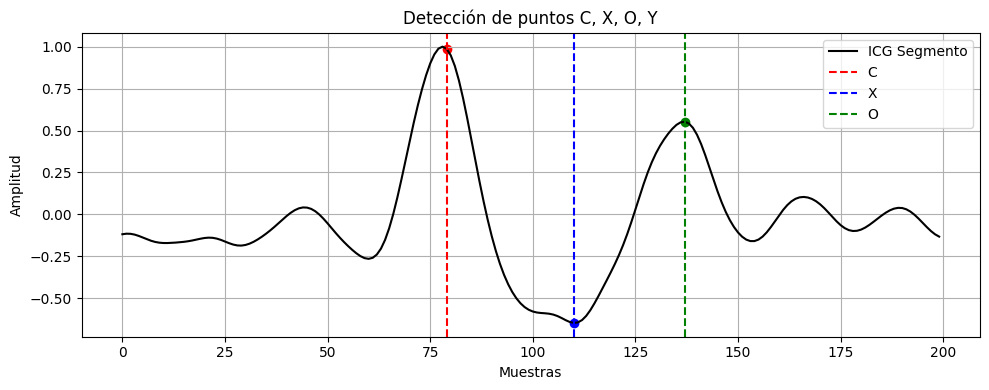

In [19]:
def detectar_punto_Y(icg_segment, resultado_X, O_index):
    # Determinar índice de inicio según el caso X
    if resultado_X["caso"] == "X":
        X_idx = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        X_idx = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        X_idx = resultado_X["X2"]  # usar X2 en este caso
    else:
        print("No se puede detectar Y: caso X no válido.")
        return None

    print("Usando X_idx en detectar_punto_Y:", X_idx)

    # Validar que X esté antes que O
    if X_idx >= O_index:
        print("No se puede detectar Y: X ocurre después de O.")
        return None

    # Extraer segmento entre X y O
    ventana_Y = icg_segment[X_idx:O_index + 1]

    # Buscar mínimos locales en esta ventana
    min_indices = argrelextrema(ventana_Y, np.less)[0]

    if len(min_indices) == 0:
        print("No se detectaron mínimos locales entre X y O.")
        return None

    # Tomar el mínimo local de menor amplitud
    Y_rel_idx = min_indices[np.argmin(ventana_Y[min_indices])]
    Y_abs_idx = X_idx + Y_rel_idx

    return Y_abs_idx


def plot_segmento_con_puntos(segmento, C_idx=None, X_idx=None, O_idx=None, Y_idx=None):
    plt.figure(figsize=(10, 4))
    plt.plot(segmento, label="ICG Segmento", color='black')

    if C_idx is not None:
        plt.axvline(x=C_idx, color='red', linestyle='--', label="C")
        plt.scatter([C_idx], [segmento[C_idx]], color='red')

    if X_idx is not None:
        plt.axvline(x=X_idx, color='blue', linestyle='--', label="X")
        plt.scatter([X_idx], [segmento[X_idx]], color='blue')

    if O_idx is not None:
        plt.axvline(x=O_idx, color='green', linestyle='--', label="O")
        plt.scatter([O_idx], [segmento[O_idx]], color='green')

    if Y_idx is not None:
        plt.axvline(x=Y_idx, color='magenta', linestyle='--', label="Y")
        plt.scatter([Y_idx], [segmento[Y_idx]], color='magenta')

    plt.legend()
    plt.title("Detección de puntos C, X, O, Y")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


segmento = v_segments['icg_segment'].iloc[1000]
fs = 250
C_index, _ = detect_C_peaks(segmento, fs)
resultado = detectar_punto_X(segmento, C_index, fs, plot=False)
C_idx = C_index[0]
O_idx = detect_O_point(segmento, C_idx, fs)
Y_idx = detectar_punto_Y(segmento, resultado, O_idx)

# Aquí usas la función externa para plotear todos los puntos
if resultado["caso"] == "X":
    X_idx = resultado["X"]
elif resultado["caso"] == "X1":
    X_idx = resultado["X1"]
elif resultado["caso"] == "X1_X2":
    X_idx = resultado["X2"]
else:
    X_idx = None

plot_segmento_con_puntos(segmento, C_idx=C_index[0], X_idx=X_idx, O_idx=O_idx, Y_idx=Y_idx)

###Delineation Algorithm for all characteristic Points:

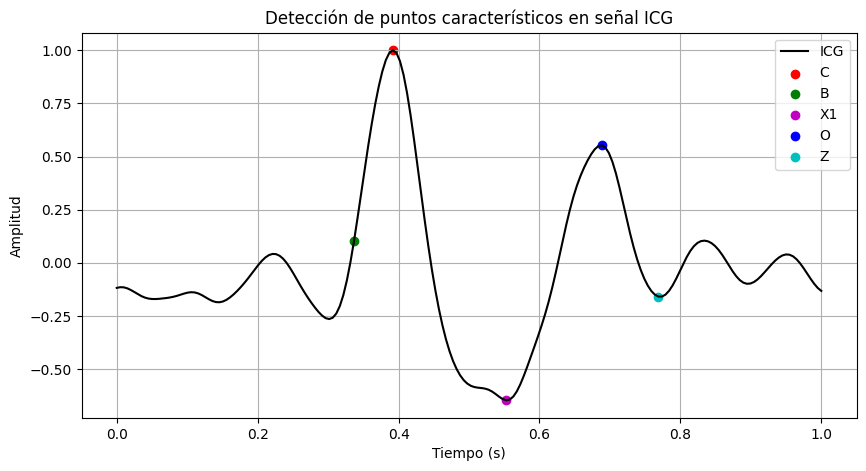

In [20]:
# ===================== #
#    1. FUNCIONES       #
# ===================== #

def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)
    for n in range(len(signal)):
        i1, i2 = max(0, n - long_len // 2), min(len(signal), n + long_len // 2)
        j1, j2 = max(0, n - short_len // 2), min(len(signal), n + short_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)
        short_energy = np.sum(signal[j1:j2] ** 2)
        if long_energy != 0:
            Xre[n] = signal[n] * (short_energy / long_energy)
    return Xre


def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)
    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 else sorted_peaks[-1]
    Thr_max, Thr_min = 0.2 * maxval, 0.02 * maxval

    C_peaks, active = [], False
    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active, start_idx = True, i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if not C_peaks or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            avg_cc = np.mean(prev_cc)
            if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                final_C_peaks.append(p)
    return np.array(final_C_peaks), Xre


def find_B_point(icg_segment, Cpos, fs, Afrac=0.2, Bslope1=0.11, Bslope2=0.08):
    BlimL = max(0, int(Cpos - 0.08 * fs))
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * icg_segment[Cpos]:
            BlimR = i
            break
    else:
        BlimR = BlimL
    slope = np.gradient(icg_segment)
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and icg_segment[i] < icg_segment[i-1]) or abs(slope[i]) > Bslope1:
            return i
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i
    return BlimL + np.argmin(icg_segment[BlimL:BlimR+1])


def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):
    # 1. Definir ventana temporal (0.05s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        X1_idx, X2_idx = min_indices[0], min_indices[1]
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        umbral = 0.05
        idx = min_indices[0]
        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    else:
        X1_idx, X2_idx, X3_idx = min_indices[:3]
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        umbral = 0.05
        idx = min_indices[0]
        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # Ajuste de índices absolutos
    if resultado["caso"] == "X":
        resultado["X"] += start
    elif resultado["caso"] == "X1":
        resultado["X1"] += start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] += start
        resultado["X2"] += start

    return resultado


def detect_O_point(segment, C_index, fs):
    start_search = C_index + int(0.2 * fs)
    end_search = min(C_index + int(0.5 * fs), len(segment))
    search_region = segment[start_search:end_search]
    if len(search_region) == 0:
        return None
    peaks, _ = signal.find_peaks(search_region)
    if len(peaks) == 0:
        return None
    max_peak_idx = peaks[np.argmax(search_region[peaks])]
    return start_search + max_peak_idx


def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the first local minimum
    Z_index = start_search + peaks[0]
    return Z_index


def detectar_punto_Y(icg_segment, resultado_X, O_index, fs):
    # Selección del índice de X
    if resultado_X["caso"] == "X":
        X_idx = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        X_idx = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        X_idx = resultado_X["X2"]
    else:
        return None

    if X_idx >= O_index:
        return None

    # Definir ventana temporal tras X
    min_offset = int(0.06 * fs)  # 60 ms
    max_offset = O_index
    inicio = X_idx + min_offset
    fin = min(X_idx + max_offset, O_index + 1)

    if fin <= inicio or fin > len(icg_segment):
        return None

    ventana_Y = icg_segment[inicio:fin]

    # Detectar mínimos locales
    min_idx = argrelextrema(ventana_Y, np.less)[0]

    for idx in min_idx:
        # Verificar que la curva baja antes y sube después (mínimo local "válido")
        if 1 <= idx < len(ventana_Y) - 1:
            if ventana_Y[idx - 1] > ventana_Y[idx] < ventana_Y[idx + 1]:
                return inicio + idx

    # Si no hay mínimos válidos con esa forma
    return None
# ===================== #
#     2. CARGA & PLOT   #
# ===================== #

fs = 200
segmento_idx = 1000
segmento = v_segments['icg_segment'].iloc[segmento_idx]

# Detectar todos los puntos
C_peaks, _ = detect_C_peaks(segmento, fs)
B_points = find_B_point(segmento, C_peaks[0], fs)
X_result = detectar_punto_X(segmento, C_peaks[0], fs)
O_point = detect_O_point(segmento, C_peaks[0], fs)
Z_point = detect_Z_point(segmento, O_point, fs)
Y_point = detectar_punto_Y(segmento, X_result, O_point, fs)

def plot_icg_with_points(icg_segment, fs,
                         C_idx, B_idxs, X_res, O_idx, Z_idx, Y_idx):
    time = np.linspace(0, len(icg_segment)/fs, len(icg_segment))
    plt.figure(figsize=(10,5))
    plt.plot(time, icg_segment, color='k', label='ICG')

    plt.scatter(time[C_idx], icg_segment[C_idx], color='r', label='C')
    plt.scatter(time[B_idxs], icg_segment[B_idxs], color='g', label='B')


    if X_res['caso']=='X':
        plt.scatter(time[X_res['X']], icg_segment[X_res['X']], color='m', label='X')
    elif X_res['caso']=='X1':
        plt.scatter(time[X_res['X1']], icg_segment[X_res['X1']], color='m', label='X1')
    elif X_res['caso']=='X1_X2':
        plt.scatter(time[X_res['X1']], icg_segment[X_res['X1']], color='m', label='X1')
        plt.scatter(time[X_res['X2']], icg_segment[X_res['X2']], color='y', label='X2')

    if O_idx is not None:
        plt.scatter(time[O_idx], icg_segment[O_idx], color='b', label='O')

    if Z_idx is not None:
        plt.scatter(time[Z_idx], icg_segment[Z_idx], color='c', label='Z')

    if Y_idx is not None:
        plt.scatter(time[Y_idx], icg_segment[Y_idx], color='orange', label='Y')

    plt.legend()
    plt.title('Detección de puntos característicos en señal ICG')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.show()

# Llamada al plot
plot_icg_with_points(segmento, fs, C_peaks[0], B_points, X_result, O_point, Z_point, Y_point)


###K-MEDOIDS + DTW (Clustering Algorithm)

####First scenario: With this algorithm we obtain the optimum K (number of clusters) according to the metrics: silhouette, davies, calinski and dunn.


K = 2

K = 3

K = 4

K = 5

K = 6

🔍 Silhouette → Best K: 3 (value: 0.2288)


<ipython-input-21-716e017a34ab>:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v_segments_sample[f'Cluster_{metric}'] = labels  # Añadir etiquetas correctas al DataFrame


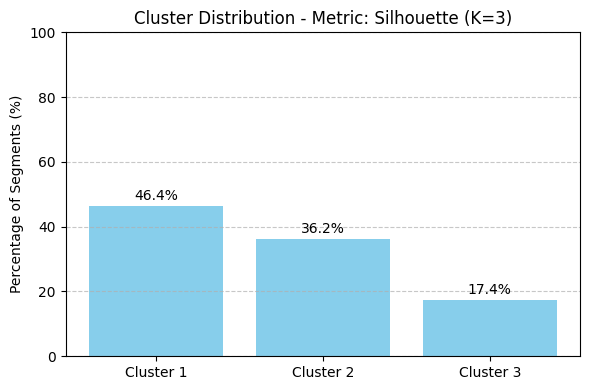

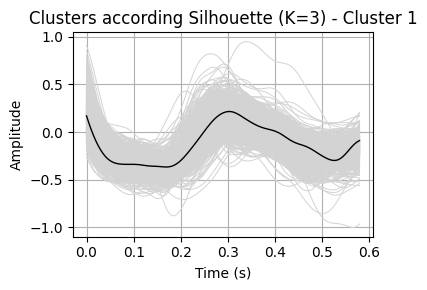

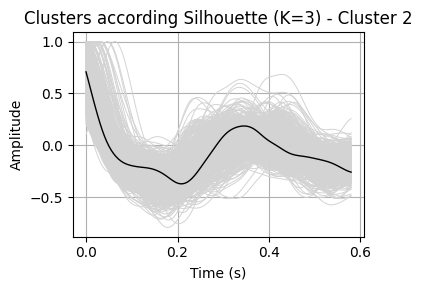

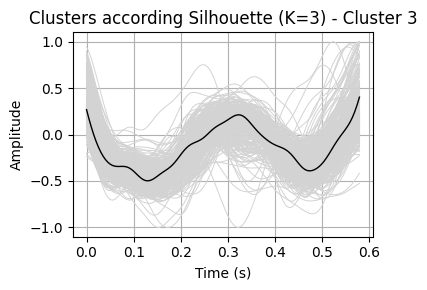


🔍 DaviesBouldin → Best K: 6 (value: 1.8176)


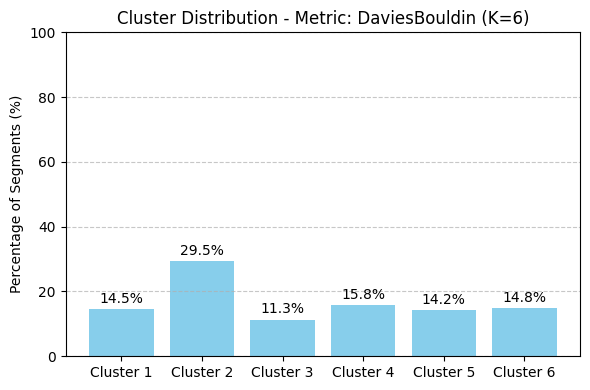

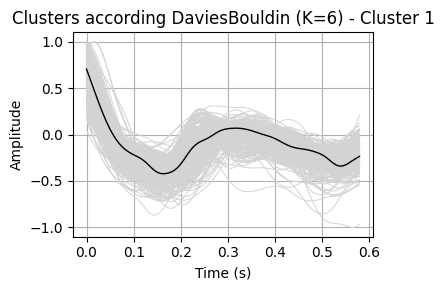

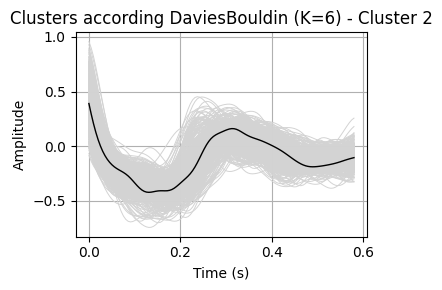

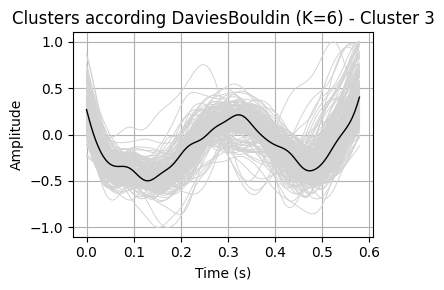

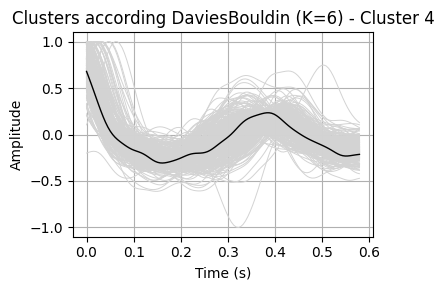

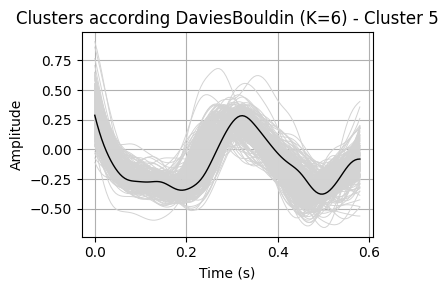

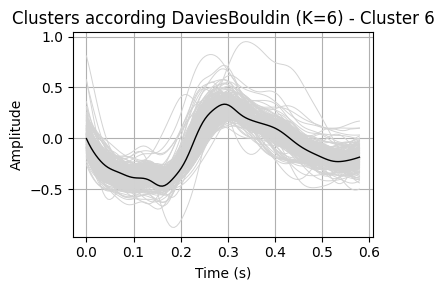


🔍 CalinskiHarabasz → Best K: 3 (value: 303.6874)


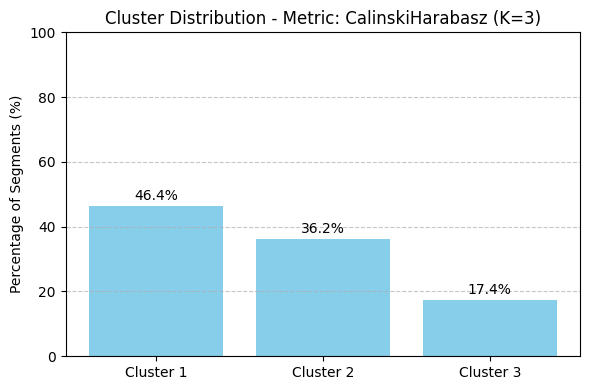

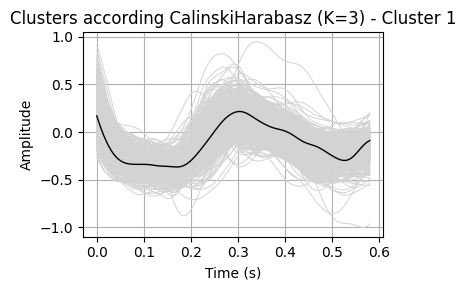

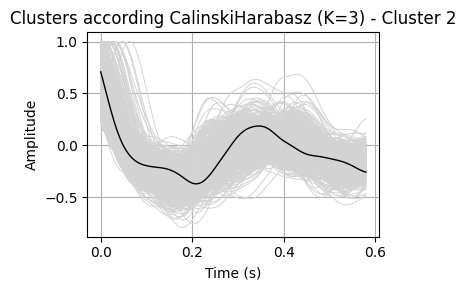

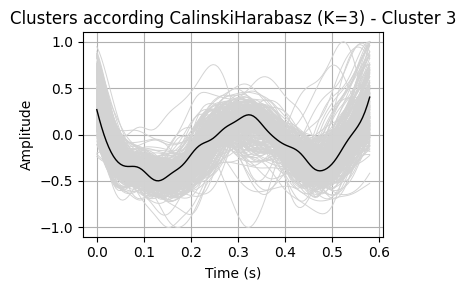


🔍 Dunn → Best K: 5 (value: 0.0342)


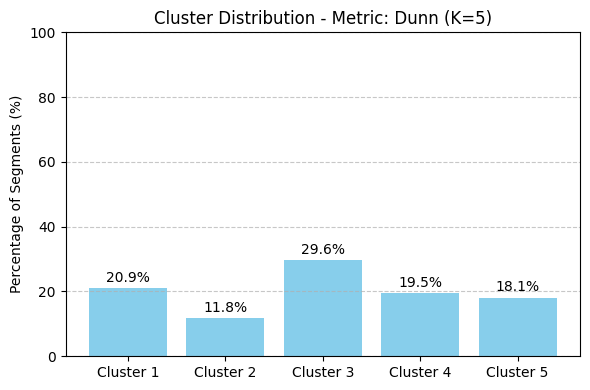

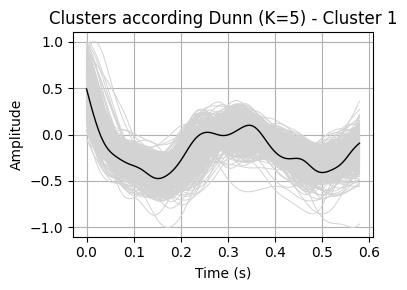

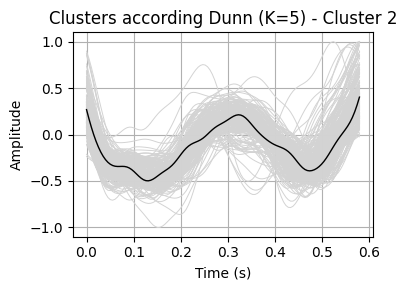

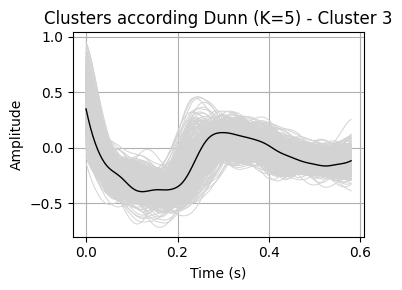

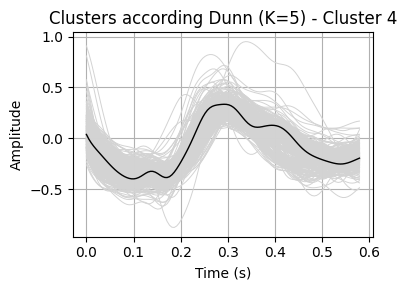

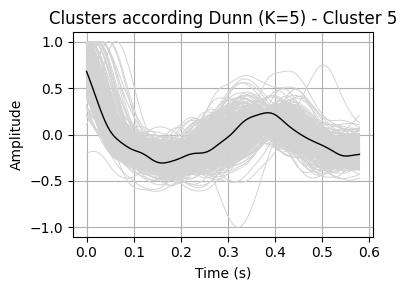

In [21]:
# Dunn Index
def dunn_index(X, labels):
    unique_labels = np.unique(labels)
    inter_cluster = []
    intra_cluster = []

    for i in unique_labels:
        cluster_i = X[labels == i]
        if len(cluster_i) < 2:
            intra_cluster.append(0)
        else:
            intra = np.max(pdist(cluster_i))
            intra_cluster.append(intra)

    for i, j in combinations(unique_labels, 2):
        cluster_i = X[labels == i]
        cluster_j = X[labels == j]
        dist = np.min([np.linalg.norm(x - y) for x in cluster_i for y in cluster_j])
        inter_cluster.append(dist)

    return np.min(inter_cluster) / np.max(intra_cluster)


# === 1. Selección de muestra y matriz DTW ===
v_segments_sample = v_segments['Segment_partial'] #al contrario que en la anterior BBDD, aquí se cogen todos los segmentos ya que hay un total
#de 1800
X = np.stack(v_segments_sample.values)
dtw_distances = cdist_dtw(X, global_constraint="sakoe_chiba", sakoe_chiba_radius=int(0.1 * X.shape[1]))
np.save("dtw_distances.npy", dtw_distances)


range_k = range(2, 7)
results = []

for k in range_k:
    print(f"\nK = {k}")
    initial_medoids = random.sample(range(len(X)), k)
    kmed = kmedoids(dtw_distances.tolist(), initial_medoids, data_type='distance_matrix')
    kmed.process()
    clusters = kmed.get_clusters()

    labels = np.empty(len(X), dtype=int)
    for idx, points in enumerate(clusters):
        labels[points] = idx

    silhouette = silhouette_score(dtw_distances, labels, metric='precomputed')
    davies = davies_bouldin_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    dunn = dunn_index(X, labels)

    results.append({
        'K': k,
        'Silhouette': silhouette,
        'DaviesBouldin': davies,
        'CalinskiHarabasz': calinski,
        'Dunn': dunn,
        'Labels': labels.copy()
    })

# === 2. Elegir mejor K según cada métrica ===
df_results = pd.DataFrame(results)

best_by = {
    'Silhouette': df_results.loc[df_results['Silhouette'].idxmax()],
    'DaviesBouldin': df_results.loc[df_results['DaviesBouldin'].idxmin()],
    'CalinskiHarabasz': df_results.loc[df_results['CalinskiHarabasz'].idxmax()],
    'Dunn': df_results.loc[df_results['Dunn'].idxmax()]
}

# === 3. Plot por cada K óptimo según métrica ===
t = np.arange(X.shape[1]) / FS
for metric, res in best_by.items():
    print(f"\n🔍 {metric} → Best K: {res['K']} (value: {res[metric]:.4f})")
    labels = res['Labels']
    v_segments_sample[f'Cluster_{metric}'] = labels  # Añadir etiquetas correctas al DataFrame

    #Añadir un plot -> cuál es la distribución de cada cluster para cada k óptimo.
    cluster_ids, counts = np.unique(labels, return_counts=True)
    total = len(labels)
    percentages = 100 * counts / total

    plt.figure(figsize=(6, 4))
    bars = plt.bar([f"Cluster {i+1}" for i in cluster_ids], percentages, color='skyblue')
    plt.ylabel("Percentage of Segments (%)")
    plt.title(f"Cluster Distribution - Metric: {metric} (K={int(res['K'])})")
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for bar, pct in zip(bars, percentages):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{pct:.1f}%", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()


    for cluster_id in np.unique(labels):
        cluster_indices = np.where(labels == cluster_id)[0]
        cluster_segments = X[cluster_indices]

        # Submatriz de distancias intra-cluster
        dist_submatrix = dtw_distances[np.ix_(cluster_indices, cluster_indices)]

        # Sumar distancias de cada segmento a todos los demás (para hallar el medoid)
        sum_distances = dist_submatrix.sum(axis=1)
        medoid_idx_within_cluster = np.argmin(sum_distances)
        medoid_idx = cluster_indices[medoid_idx_within_cluster]

        # Segmento representante (medoide real)
        representative_segment = X[medoid_idx]

        # Crear figura
        plt.figure(figsize=(4, 3))

        # Dibujar todos los segmentos del cluster en gris claro
        for segment in cluster_segments:
            plt.plot(t, segment, color='lightgray', linewidth=0.7)

        # Dibujar el segmento representante (medoide) en azul oscuro
        plt.plot(t, representative_segment, color='black', linewidth=1)

        plt.title(f'Clusters according {metric} (K={int(res["K"])}) - Cluster {cluster_id+1}')
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


####Second senario: with this algorithm we obtain the optim number of clusters according to the elbow rule

Cargando matriz de distancias DTW guardada...
Trying different values of K...
 - Clustering with K = 2


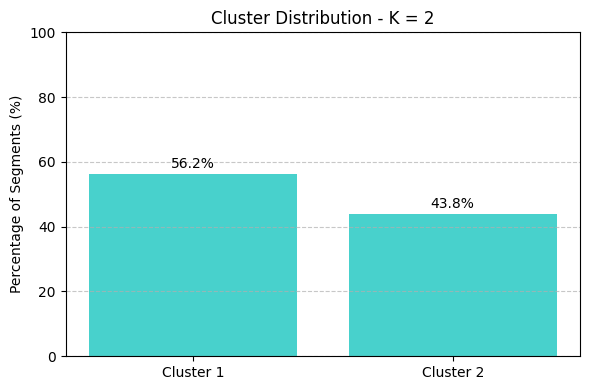

   → Medium distance intra-cluster: 1.4192


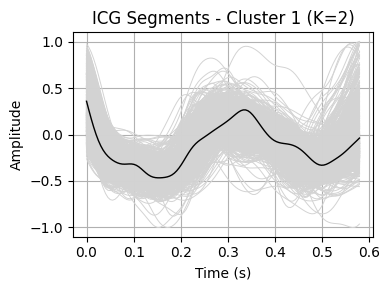

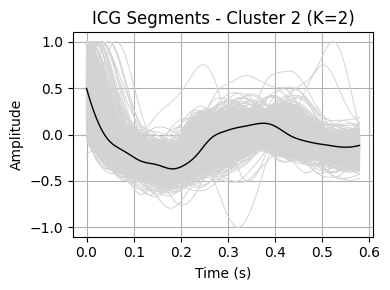

 - Clustering with K = 3


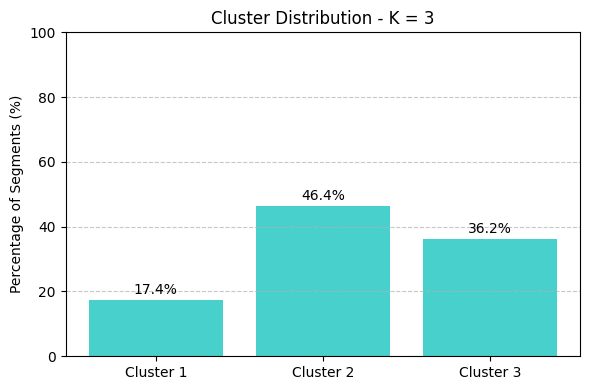

   → Medium distance intra-cluster: 1.3459


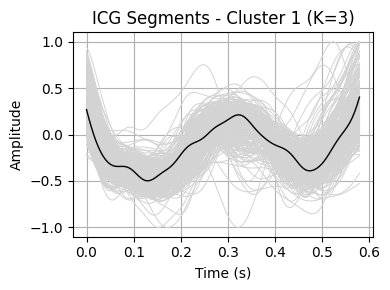

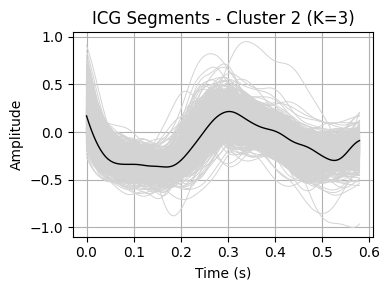

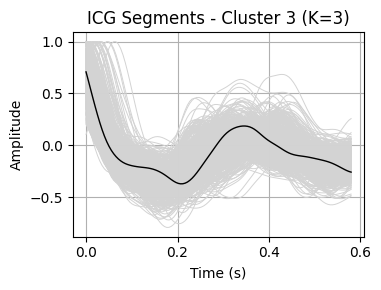

 - Clustering with K = 4


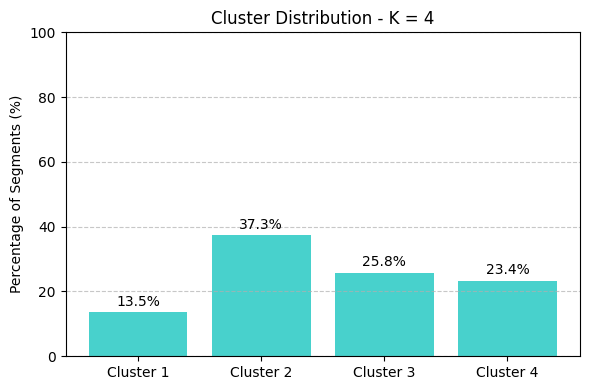

   → Medium distance intra-cluster: 1.2455


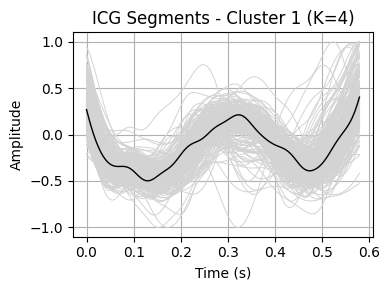

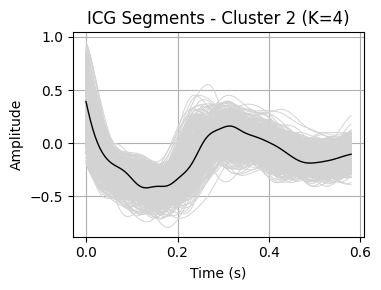

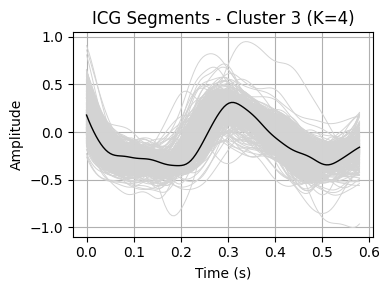

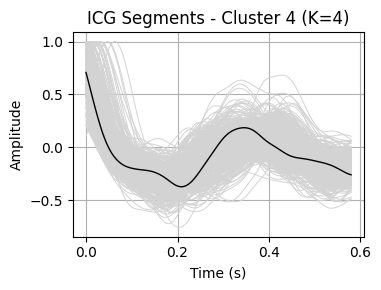

 - Clustering with K = 5


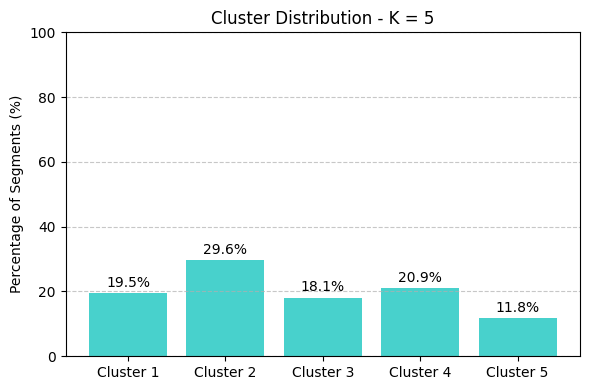

   → Medium distance intra-cluster: 1.1263


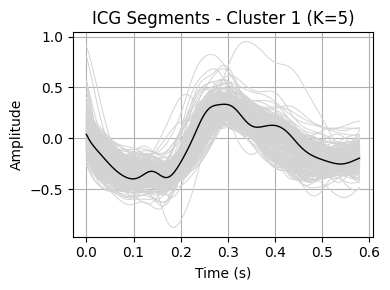

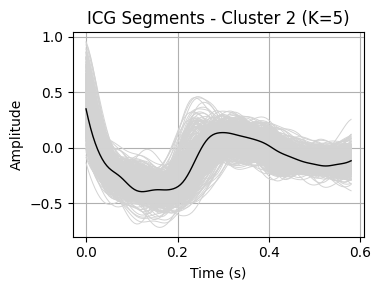

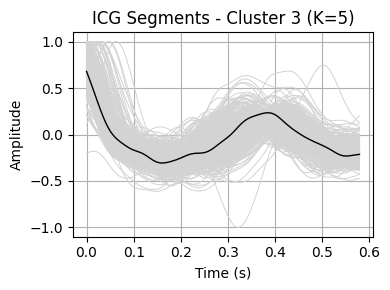

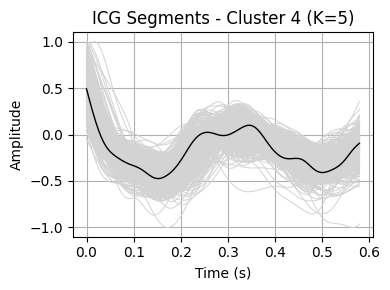

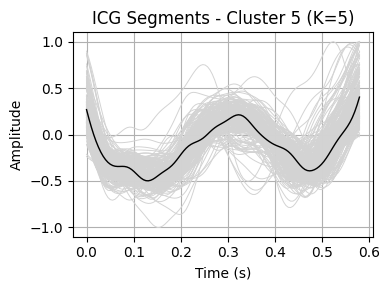

 - Clustering with K = 6


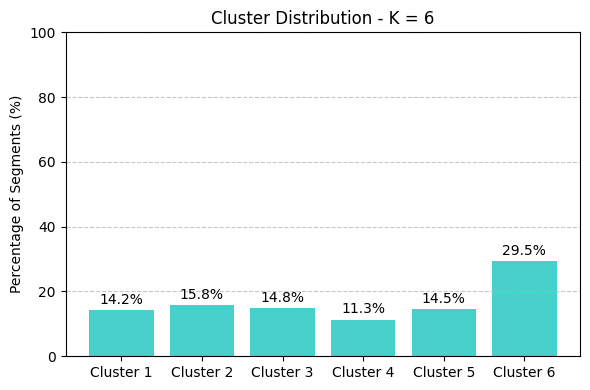

   → Medium distance intra-cluster: 1.0615


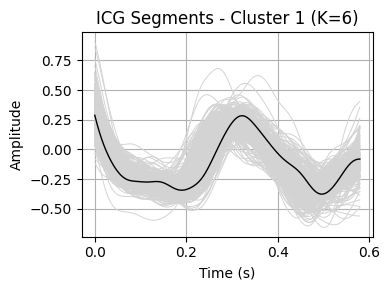

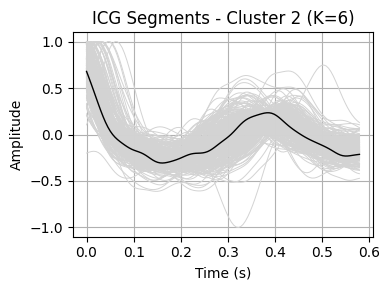

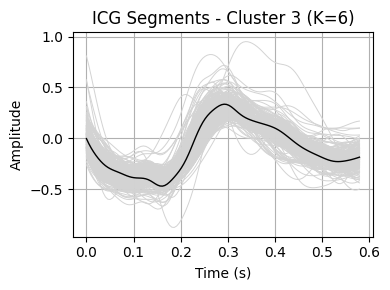

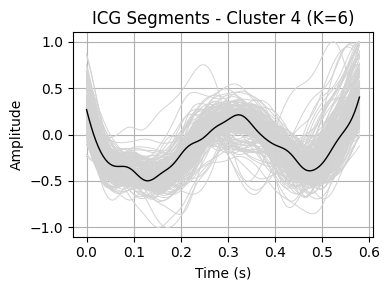

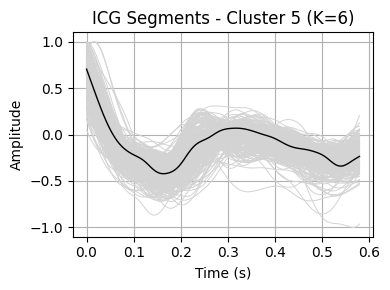

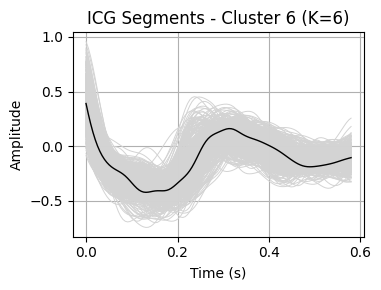

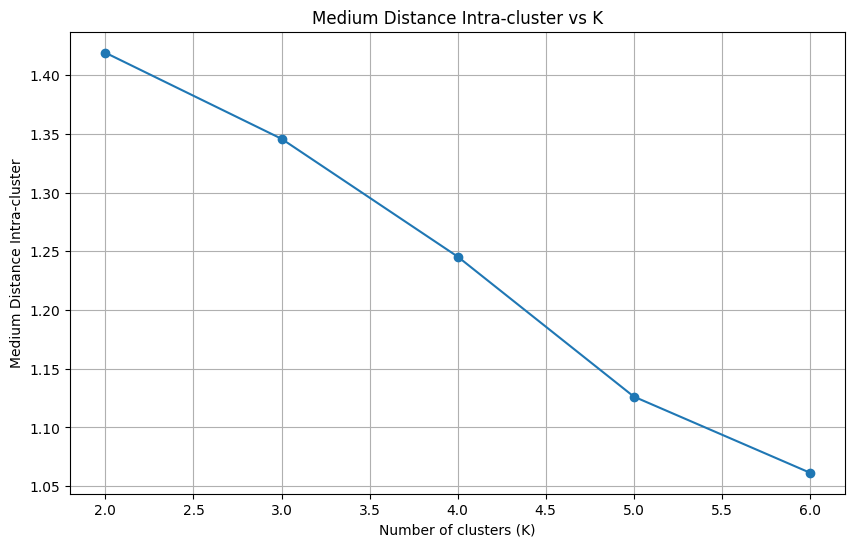

In [22]:
# 1. Cargar datos
v_segments_sample = v_segments['Segment_partial']
X = np.stack(v_segments_sample.values)

# 2. Calcular o cargar la matriz de distancias DTW
if os.path.exists("dtw_distances.npy"):
    print("Cargando matriz de distancias DTW guardada...")
    dtw_distances = np.load("dtw_distances.npy")
else:
    print("Calculando matriz de distancias DTW...")
    window_size = int(0.1 * X.shape[1])
    dtw_distances = cdist_dtw(X, global_constraint="sakoe_chiba", sakoe_chiba_radius=window_size)
    np.save("dtw_distances.npy", dtw_distances)


# 3. Función para calcular distancia promedio intra-cluster
def intra_cluster_distance(k, labels, dtw_distances):
    intra_cluster_distances = []

    for cluster_id in range(k):
        cluster_points = np.where(labels == cluster_id)[0]
        if len(cluster_points) > 1:
            # Calcular la distancia promedio entre todos los pares de segmentos dentro del cluster
            distances = dtw_distances[cluster_points[:, None], cluster_points]
            intra_cluster_distances.append(np.mean(distances))  # Promedio de las distancias DTW dentro del cluster
        else:
            intra_cluster_distances.append(0)  # Si solo hay un elemento en el cluster, la distancia es 0

    return np.mean(intra_cluster_distances)  # Promedio de todas las distancias intra-cluster para este K

# 4. Probar distintos valores de K (2 a 6)
intra_cluster_distances_per_k = {}

print("Trying different values of K...")
for k in range(2, 7):
    print(f" - Clustering with K = {k}")

    # Elegir k índices aleatorios como medoids iniciales
    initial_medoids = random.sample(range(len(X)), k)

    # Crear e inicializar el algoritmo con matriz de distancias
    kmedoids_instance = kmedoids(dtw_distances.tolist(), initial_medoids, data_type='distance_matrix')

    # Ejecutar el clustering
    kmedoids_instance.process()

    # Obtener los clusters
    clusters = kmedoids_instance.get_clusters()

    # Crear array de etiquetas
    labels = np.empty(len(X), dtype=int)
    for cluster_id, cluster_points in enumerate(clusters):
        labels[cluster_points] = cluster_id

    #Distribution of each cluster
    cluster_ids, counts = np.unique(labels, return_counts=True)
    total = len(labels)
    percentages = 100 * counts / total

    plt.figure(figsize=(6, 4))
    bars = plt.bar([f"Cluster {i+1}" for i in cluster_ids], percentages, color='mediumturquoise')
    plt.ylabel("Percentage of Segments (%)")
    plt.title(f"Cluster Distribution - K = {k}")
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for bar, pct in zip(bars, percentages):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{pct:.1f}%", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

    # Evaluar la distancia promedio intra-cluster
    mean_intra_cluster_distance = intra_cluster_distance(k, labels, dtw_distances)
    intra_cluster_distances_per_k[k] = mean_intra_cluster_distance
    print(f"   → Medium distance intra-cluster: {mean_intra_cluster_distance:.4f}")

    # Crear los plots de los clusters con mejoras visuales
    t = np.arange(X.shape[1]) / FS
    for cluster_id in range(k):
        cluster_indices = np.where(labels == cluster_id)[0]
        cluster_segments = X[cluster_indices]

        if cluster_segments.shape[0] == 0:
            continue  # Evitar clusters vacíos

        # Extraer la submatriz de distancias DTW entre los segmentos de este cluster
        dist_submatrix = dtw_distances[np.ix_(cluster_indices, cluster_indices)]

        # Sumar distancias de cada segmento al resto para encontrar el medoid
        sum_distances = dist_submatrix.sum(axis=1)
        medoid_idx_within_cluster = np.argmin(sum_distances)
        medoid_idx = cluster_indices[medoid_idx_within_cluster]

        # Segmento representativo = medoid (segmento real dentro del cluster)
        representative_segment = X[medoid_idx]

        plt.figure(figsize=(4, 3))

        # Dibujar todos los segmentos en gris claro
        for segment in cluster_segments:
            plt.plot(t, segment, color='lightgray', linewidth=0.7)

        # Dibujar el segmento representativo en azul oscuro
        plt.plot(t, representative_segment, color='black', linewidth=1)

        plt.title(f'ICG Segments - Cluster {cluster_id+1} (K={k})')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.tight_layout()
        plt.show()


# Mostrar las distancias intra-cluster para cada K
plt.figure(figsize=(10, 6))
plt.plot(list(intra_cluster_distances_per_k.keys()), list(intra_cluster_distances_per_k.values()), marker='o')
plt.title('Medium Distance Intra-cluster vs K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Medium Distance Intra-cluster')
plt.grid(True)
plt.show()


In [23]:
#Se aplica la técnica del codo para hallar K óptimo.

# Detectar punto del codo ignorando el primer salto (1 -> 2). Esto se hace porque si K se obtiene por caída más brusca evidentemente se obtiene
# que es en k=2 mientras que este puede no ser el valor óptimo.

# Extraer los valores de K y sus distancias intra-cluster
Ks = np.array(list(intra_cluster_distances_per_k.keys()))
distances = np.array(list(intra_cluster_distances_per_k.values()))

# Aplicar método del codo, ignorando el primer salto para evitar que devuelva K=2 por defecto
kneedle = KneeLocator(Ks, distances, curve='convex', direction='decreasing')

if kneedle.knee is not None:
    optimal_k = kneedle.knee
    print(f"\n✅ K óptimo detectado automáticamente con método del codo: K = {optimal_k}")
else:
    # Si no se detecta un codo claro, seleccionamos el mayor descenso RELATIVO excluyendo el primero
    relative_diffs = np.diff(distances) / distances[:-1]  # cambios relativos
    best_index = np.argmin(relative_diffs[1:]) + 1  # +1 porque ignoramos salto K=2
    optimal_k = Ks[best_index]
    print(f"\n⚠️ No se detectó un codo claro. Se selecciona K = {optimal_k} como el de mayor descenso relativo tras K=2.")

# Si quieres guardar este K óptimo para luego usarlo:
k_optimo = optimal_k

import pandas as pd

# Volver a aplicar clustering sobre la muestra con el K óptimo
print(f"\n🔁 Aplicando clustering final con K = {optimal_k}...")
initial_medoids = random.sample(range(len(X)), optimal_k)
final_kmedoids = kmedoids(dtw_distances.tolist(), initial_medoids, data_type='distance_matrix')
final_kmedoids.process()
final_clusters = final_kmedoids.get_clusters()

# Crear etiquetas finales
final_labels = np.empty(len(X), dtype=int)
for cluster_id, cluster_points in enumerate(final_clusters):
    final_labels[cluster_points] = cluster_id

# Crear tabla de clusters con los segmentos completos
cluster_table = pd.DataFrame(columns=[f'Cluster_{i}' for i in range(optimal_k)])

# Importante: obtener los índices originales de los segmentos muestreados
original_indices = v_segments.index

# Asignar los segmentos completos a la tabla por cluster
for i, label in enumerate(final_labels):
    idx = original_indices[i]  # Índice en el DataFrame original
    full_segment = v_segments.loc[idx, 'icg_segment']
    row = [None] * optimal_k
    row[label] = full_segment
    cluster_table.loc[len(cluster_table)] = row

# Mostrar resumen
print(f"✅ Tabla de segmentos agrupados por cluster generada con {len(cluster_table)} filas.")
print(cluster_table.head())

# Guardar tabla en CSV
cluster_table.to_csv('tabla_clusters_segmentos_completos_2_scenario.csv', index=False)



✅ K óptimo detectado automáticamente con método del codo: K = 2

🔁 Aplicando clustering final con K = 2...
✅ Tabla de segmentos agrupados por cluster generada con 1657 filas.
                                           Cluster_0 Cluster_1
0  [-0.0879120428378609, -0.0978801295061101, -0....      None
1  [-0.06942069528769894, -0.07176496233766803, -...      None
2  [-0.059054204545974404, -0.06793791125007255, ...      None
3  [-0.016860400336395357, -0.024696119334679554,...      None
4  [-0.11504064068538182, -0.12164844524542653, -...      None


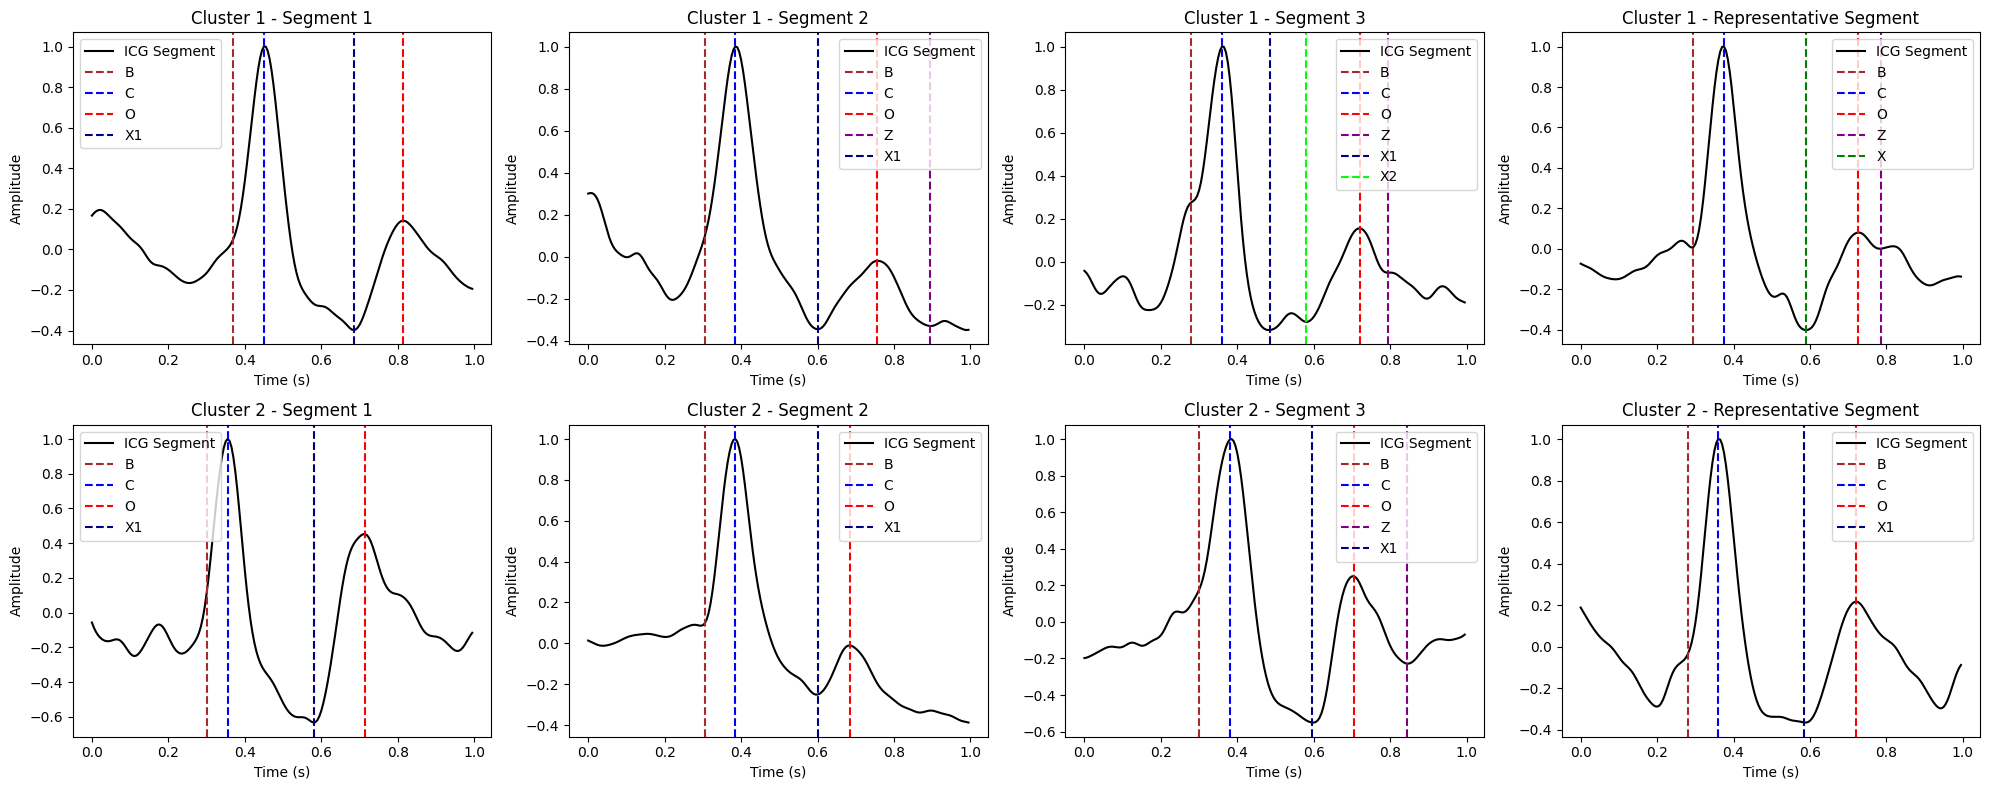

In [24]:
N = 3  # Número de segmentos a visualizar por cluster
fs = 200  # Frecuencia de muestreo

def plot_segment_with_points(ax, segment, points, fs, title=""):
    t = np.arange(len(segment)) / fs  # Vector de tiempo en segundos
    ax.plot(t, segment, label='ICG Segment', color='black')
    colors = {
        "B": "brown", "C": "blue", "X": "green", "X1": "navy", "X2": "lime",
        "O": "red", "Z": "purple", "Y": "orange"
    }
    for label, index in points.items():
        if index is not None:
            ax.axvline(index / fs, color=colors.get(label, 'black'), linestyle='--', label=label)
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')


def calculate_medoid_segment(segments):
    min_len = min(len(s) for s in segments)
    trimmed_segments = [s[:min_len] for s in segments]
    n = len(trimmed_segments)

    # Matriz de distancias
    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(trimmed_segments[i] - trimmed_segments[j])
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist

    # Suma de distancias para cada segmento
    dist_sums = dist_matrix.sum(axis=1)

    # Índice del médoid (menor suma de distancias)
    medoid_idx = np.argmin(dist_sums)

    return trimmed_segments[medoid_idx]

num_clusters = k_optimo
fig, axes = plt.subplots(num_clusters, N + 1, figsize=(5 * (N + 1), 4 * num_clusters))

for cluster_id in range(num_clusters):
    # Extraer todos los segmentos del cluster actual, eliminando valores nulos
    segments = cluster_table[f'Cluster_{cluster_id}'].dropna().tolist()

    if len(segments) == 0:
        print(f"⚠️ Cluster {cluster_id} vacío.")
        continue

    # Seleccionar N segmentos aleatorios
    random.seed() #Esto se añade para que el segmento sea elegido aleatoriamente en cada ejecución
    selected_segments = random.sample(segments, min(N, len(segments)))

    # Calcular el segmento representativo
    representative_segment = calculate_medoid_segment(segments)

    # Detectar puntos característicos en el segmento representativo
    C_peaks, _ = detect_C_peaks(representative_segment, fs)
    if len(C_peaks) == 0:
        print(f"⚠️ Cluster {cluster_id}: no se detectó pico C en el segmento representativo.")
        continue
    C_index = C_peaks[0]
    B_index = find_B_point(representative_segment, C_index, fs)
    resultado_X = detectar_punto_X(representative_segment, C_index, fs)
    O_index = detect_O_point(representative_segment, C_index, fs)
    Z_index = detect_Z_point(representative_segment, O_index, fs) if O_index else None
    Y_index = detectar_punto_Y(representative_segment, resultado_X, O_index, fs)

    puntos_repr = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
    if resultado_X["caso"] == "X":
        puntos_repr["X"] = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        puntos_repr["X1"] = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        puntos_repr["X1"] = resultado_X["X1"]
        puntos_repr["X2"] = resultado_X["X2"]

    # Plot de segmentos individuales
    for i, segment in enumerate(selected_segments):
        C_peaks, _ = detect_C_peaks(segment, fs)
        if len(C_peaks) == 0:
            print(f"⚠️ Segmento en Cluster {cluster_id}: sin pico C.")
            continue
        C_index = C_peaks[0]
        B_index = find_B_point(segment, C_index, fs)
        resultado_X = detectar_punto_X(segment, C_index, fs)
        O_index = detect_O_point(segment, C_index, fs)
        Z_index = detect_Z_point(segment, O_index, fs) if O_index else None
        Y_index = detectar_punto_Y(segment, resultado_X, O_index, fs)

        puntos = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
        if resultado_X["caso"] == "X":
            puntos["X"] = resultado_X["X"]
        elif resultado_X["caso"] == "X1":
            puntos["X1"] = resultado_X["X1"]
        elif resultado_X["caso"] == "X1_X2":
            puntos["X1"] = resultado_X["X1"]
            puntos["X2"] = resultado_X["X2"]

        plot_segment_with_points(axes[cluster_id, i], segment, puntos, fs, title=f"Cluster {cluster_id+1} - Segment {i+1}")

    # Plot del segmento representativo
    plot_segment_with_points(axes[cluster_id, N], representative_segment, puntos_repr, fs, title=f"Cluster {cluster_id +1} - Representative Segment")

plt.tight_layout()
plt.show()


####Third scenario: we put the K that we consider

Here I think that if the optimal K obtained is not the one I consider optimal, what I should do is create a script that, for the K I specify, is able to store the segments in a table structured like the one used for the optimal K: as many columns as the K I’ve specified, and as many rows as segments stored in each cluster. This would be useful later to apply the point delineation algorithms on those stored clusters, since currently only those for the optimal K are saved.

In [25]:
# 🔧 Define aquí el K manual deseado
k_manual = 5

print(f"\n🔁 Aplicando clustering manual con K = {k_manual}...")

# Aplica clustering con K manual
random.seed(42)
initial_medoids_manual = random.sample(range(len(X)), k_manual)
kmedoids_manual = kmedoids(dtw_distances.tolist(), initial_medoids_manual, data_type='distance_matrix')
kmedoids_manual.process()
clusters_manual = kmedoids_manual.get_clusters()

# Crear etiquetas manuales
labels_manual = np.empty(len(X), dtype=int)
for cluster_id, cluster_points in enumerate(clusters_manual):
    labels_manual[cluster_points] = cluster_id

# Crear tabla de clusters con los segmentos completos para K manual
cluster_table_manual = pd.DataFrame(columns=[f'Cluster_{i}' for i in range(k_manual)])

# Índices reales
original_indices = v_segments.index

# Asignar los segmentos completos a la tabla por cluster
for i, label in enumerate(labels_manual):
    idx = original_indices[i]
    full_segment = v_segments.loc[idx, 'icg_segment']
    row = [None] * k_manual
    row[label] = full_segment
    cluster_table_manual.loc[len(cluster_table_manual)] = row

# Mostrar resumen
print(f"✅ Tabla para K = {k_manual} generada con {len(cluster_table_manual)} filas.")
print(cluster_table_manual.head())

# Guardar en CSV con nombre personalizado
cluster_table_manual.to_csv(f'tabla_clusters_segmentos_completos_K{k_manual}.csv', index=False)



🔁 Aplicando clustering manual con K = 5...
✅ Tabla para K = 5 generada con 1657 filas.
  Cluster_0 Cluster_1                                          Cluster_2  \
0      None      None  [-0.0879120428378609, -0.0978801295061101, -0....   
1      None      None  [-0.06942069528769894, -0.07176496233766803, -...   
2      None      None  [-0.059054204545974404, -0.06793791125007255, ...   
3      None      None  [-0.016860400336395357, -0.024696119334679554,...   
4      None      None  [-0.11504064068538182, -0.12164844524542653, -...   

  Cluster_3 Cluster_4  
0      None      None  
1      None      None  
2      None      None  
3      None      None  
4      None      None  



📊 Segment Distribution in Clusters


Cluster,number of segments,total %
Cluster_0,347,20.9%
Cluster_1,300,18.1%
Cluster_2,491,29.6%
Cluster_3,196,11.8%
Cluster_4,323,19.5%


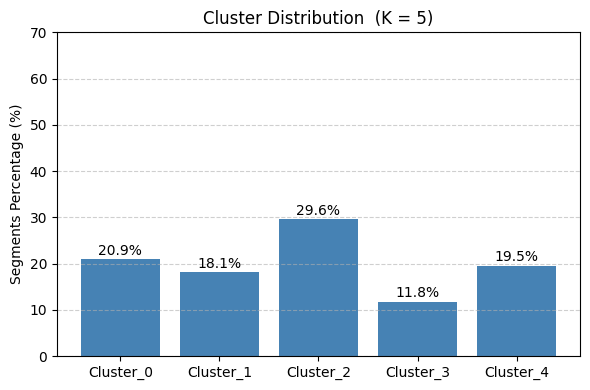

In [26]:
# ============================================================
# 🔎  Distribución de segmentos por cluster  (tabla + gráfico)
# ============================================================

# 1. Conteos absolutos y porcentajes -------------------------
cluster_counts = cluster_table_manual.count()           # nº de segmentos por columna
cluster_perc   = 100 * cluster_counts / cluster_counts.sum()

dist_df = pd.DataFrame({
    "Cluster": cluster_counts.index,
    "number of segments": cluster_counts.values,
    "total %": cluster_perc.round(1)
})

# 2. Mostrar la tabla formateada -----------------------------
print("\n📊 Segment Distribution in Clusters")
display(  # si usas Jupyter; si no, usa print(dist_df.to_string(index=False))
    dist_df.style
        .hide(axis="index")
        .set_table_styles([{"selector":"th","props":[("text-align","center")]}])
        .format({"total %": "{:.1f}%"})
)

# 3. Gráfico de barras ---------------------------------------
plt.figure(figsize=(6,4))
plt.bar(dist_df["Cluster"], dist_df["total %"], color="steelblue")
plt.ylabel("Segments Percentage (%)")
plt.title(f"Cluster Distribution  (K = {k_manual})")
plt.ylim(0, 70)
plt.grid(axis="y", linestyle="--", alpha=0.6)
for x, pct in zip(dist_df["Cluster"], dist_df["total %"]):
    plt.text(x, pct + 1, f"{pct:.1f}%", ha="center")
plt.tight_layout()
plt.show()


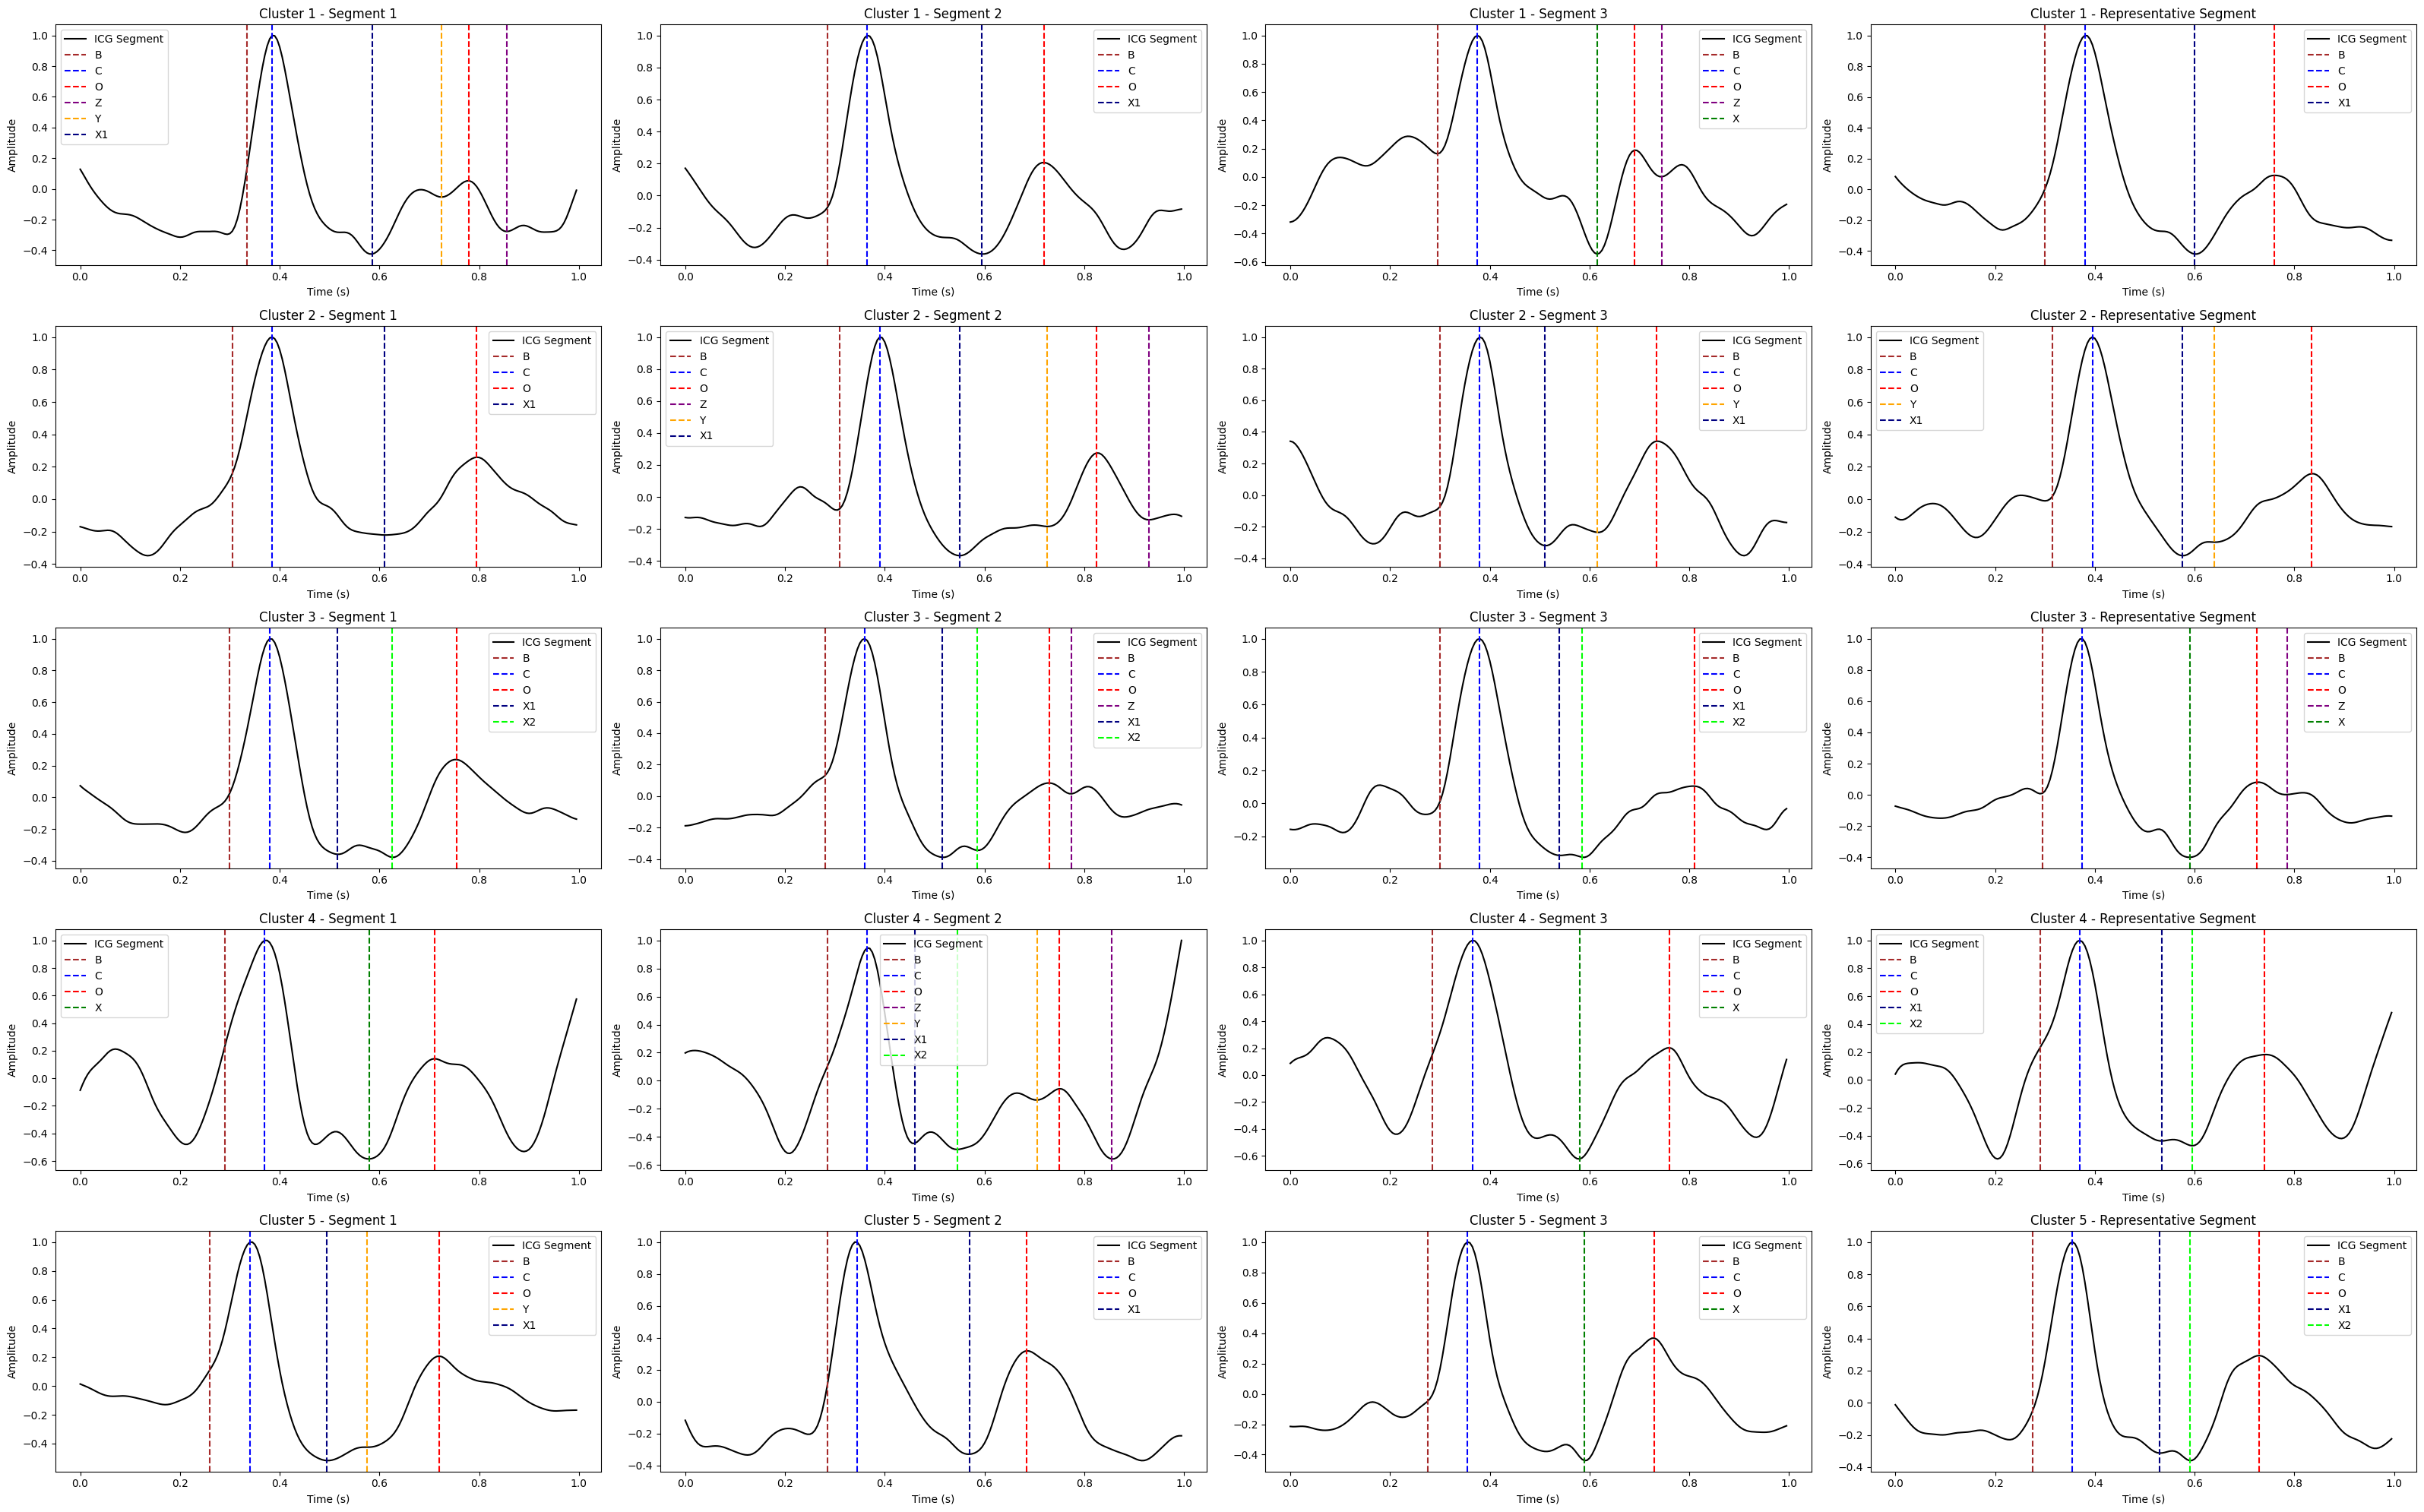

In [27]:
N = 3  # Número de segmentos a visualizar por cluster
fs = 200  # Frecuencia de muestreo

def plot_segment_with_points(ax, segment, points, fs, title=""):
    t = np.arange(len(segment)) / fs  # Vector de tiempo en segundos
    ax.plot(t, segment, label='ICG Segment', color='black')
    colors = {
        "B": "brown", "C": "blue", "X": "green", "X1": "navy", "X2": "lime",
        "O": "red", "Z": "purple", "Y": "orange"
    }
    for label, index in points.items():
        if index is not None:
            ax.axvline(index / fs, color=colors.get(label, 'black'), linestyle='--', label=label)
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')


def calculate_medoid_segment(segments):
    min_len = min(len(s) for s in segments)
    trimmed_segments = [s[:min_len] for s in segments]
    n = len(trimmed_segments)

    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(trimmed_segments[i] - trimmed_segments[j])
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist

    dist_sums = dist_matrix.sum(axis=1)
    medoid_idx = np.argmin(dist_sums)

    return trimmed_segments[medoid_idx]


num_clusters = k_manual
fig, axes = plt.subplots(num_clusters, N + 1, figsize=(8 * (N + 1), 4 * num_clusters))

for cluster_id in range(num_clusters):
    # Extraer todos los segmentos del cluster actual, eliminando valores nulos
    segments = cluster_table_manual[f'Cluster_{cluster_id}'].dropna().tolist()

    if len(segments) == 0:
        print(f"⚠️ Cluster {cluster_id} vacío.")
        continue

    # Seleccionar N segmentos aleatorios
    random.seed()
    selected_segments = random.sample(segments, min(N, len(segments)))

    # Calcular el segmento representativo
    representative_segment = calculate_medoid_segment(segments)

    # Detectar puntos característicos en el segmento representativo
    C_peaks, _ = detect_C_peaks(representative_segment, fs)
    if len(C_peaks) == 0:
        print(f"⚠️ Cluster {cluster_id}: no se detectó pico C en el segmento representativo.")
        continue
    C_index = C_peaks[0]
    B_index = find_B_point(representative_segment, C_index, fs)
    resultado_X = detectar_punto_X(representative_segment, C_index, fs)
    O_index = detect_O_point(representative_segment, C_index, fs)
    Z_index = detect_Z_point(representative_segment, O_index, fs) if O_index else None
    Y_index = detectar_punto_Y(representative_segment, resultado_X, O_index, fs)

    puntos_repr = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
    if resultado_X["caso"] == "X":
        puntos_repr["X"] = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        puntos_repr["X1"] = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        puntos_repr["X1"] = resultado_X["X1"]
        puntos_repr["X2"] = resultado_X["X2"]

    # Plot de segmentos individuales
    for i, segment in enumerate(selected_segments):
        C_peaks, _ = detect_C_peaks(segment, fs)
        if len(C_peaks) == 0:
            print(f"⚠️ Segmento en Cluster {cluster_id}: sin pico C.")
            continue
        C_index = C_peaks[0]
        B_index = find_B_point(segment, C_index, fs)
        resultado_X = detectar_punto_X(segment, C_index, fs)
        O_index = detect_O_point(segment, C_index, fs)
        Z_index = detect_Z_point(segment, O_index, fs) if O_index else None
        Y_index = detectar_punto_Y(segment, resultado_X, O_index, fs)

        puntos = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
        if resultado_X["caso"] == "X":
            puntos["X"] = resultado_X["X"]
        elif resultado_X["caso"] == "X1":
            puntos["X1"] = resultado_X["X1"]
        elif resultado_X["caso"] == "X1_X2":
            puntos["X1"] = resultado_X["X1"]
            puntos["X2"] = resultado_X["X2"]

        plot_segment_with_points(axes[cluster_id, i], segment, puntos, fs, title=f"Cluster {cluster_id+1} - Segment {i+1}")

    # Plot del segmento representativo
    plot_segment_with_points(axes[cluster_id, N], representative_segment, puntos_repr, fs, title=f"Cluster {cluster_id+1} - Representative Segment")

plt.tight_layout()
plt.show()


In [28]:
# 🔧 Define aquí el K manual deseado
k_manual = 4

print(f"\n🔁 Aplicando clustering manual con K = {k_manual}...")

# Aplica clustering con K manual
random.seed(42)
initial_medoids_manual = random.sample(range(len(X)), k_manual)
kmedoids_manual = kmedoids(dtw_distances.tolist(), initial_medoids_manual, data_type='distance_matrix')
kmedoids_manual.process()
clusters_manual = kmedoids_manual.get_clusters()

# Crear etiquetas manuales
labels_manual = np.empty(len(X), dtype=int)
for cluster_id, cluster_points in enumerate(clusters_manual):
    labels_manual[cluster_points] = cluster_id

# Crear tabla de clusters con los segmentos completos para K manual
cluster_table_manual = pd.DataFrame(columns=[f'Cluster_{i}' for i in range(k_manual)])

# Índices reales
original_indices = v_segments.index

# Asignar los segmentos completos a la tabla por cluster
for i, label in enumerate(labels_manual):
    idx = original_indices[i]
    full_segment = v_segments.loc[idx, 'icg_segment']
    row = [None] * k_manual
    row[label] = full_segment
    cluster_table_manual.loc[len(cluster_table_manual)] = row

# Mostrar resumen
print(f"✅ Tabla para K = {k_manual} generada con {len(cluster_table_manual)} filas.")
print(cluster_table_manual.head())

# Guardar en CSV con nombre personalizado
cluster_table_manual.to_csv(f'tabla_clusters_segmentos_completos_K{k_manual}.csv', index=False)



🔁 Aplicando clustering manual con K = 4...
✅ Tabla para K = 4 generada con 1657 filas.
  Cluster_0 Cluster_1                                          Cluster_2  \
0      None      None  [-0.0879120428378609, -0.0978801295061101, -0....   
1      None      None  [-0.06942069528769894, -0.07176496233766803, -...   
2      None      None  [-0.059054204545974404, -0.06793791125007255, ...   
3      None      None  [-0.016860400336395357, -0.024696119334679554,...   
4      None      None  [-0.11504064068538182, -0.12164844524542653, -...   

  Cluster_3  
0      None  
1      None  
2      None  
3      None  
4      None  



📊 Segment Distribution in Clusters


Cluster,number of segments,total %
Cluster_0,428,25.8%
Cluster_1,387,23.4%
Cluster_2,618,37.3%
Cluster_3,224,13.5%


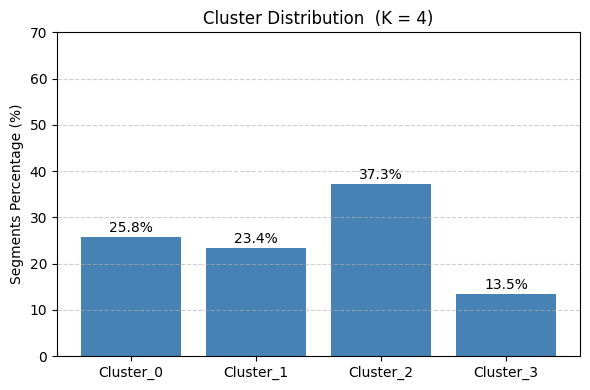

In [29]:
# ============================================================
# 🔎  Distribución de segmentos por cluster  (tabla + gráfico)
# ============================================================

# 1. Conteos absolutos y porcentajes -------------------------
cluster_counts = cluster_table_manual.count()           # nº de segmentos por columna
cluster_perc   = 100 * cluster_counts / cluster_counts.sum()

dist_df = pd.DataFrame({
    "Cluster": cluster_counts.index,
    "number of segments": cluster_counts.values,
    "total %": cluster_perc.round(1)
})

# 2. Mostrar la tabla formateada -----------------------------
print("\n📊 Segment Distribution in Clusters")
display(  # si usas Jupyter; si no, usa print(dist_df.to_string(index=False))
    dist_df.style
        .hide(axis="index")
        .set_table_styles([{"selector":"th","props":[("text-align","center")]}])
        .format({"total %": "{:.1f}%"})
)

# 3. Gráfico de barras ---------------------------------------
plt.figure(figsize=(6,4))
plt.bar(dist_df["Cluster"], dist_df["total %"], color="steelblue")
plt.ylabel("Segments Percentage (%)")
plt.title(f"Cluster Distribution  (K = {k_manual})")
plt.ylim(0, 70)
plt.grid(axis="y", linestyle="--", alpha=0.6)
for x, pct in zip(dist_df["Cluster"], dist_df["total %"]):
    plt.text(x, pct + 1, f"{pct:.1f}%", ha="center")
plt.tight_layout()
plt.show()


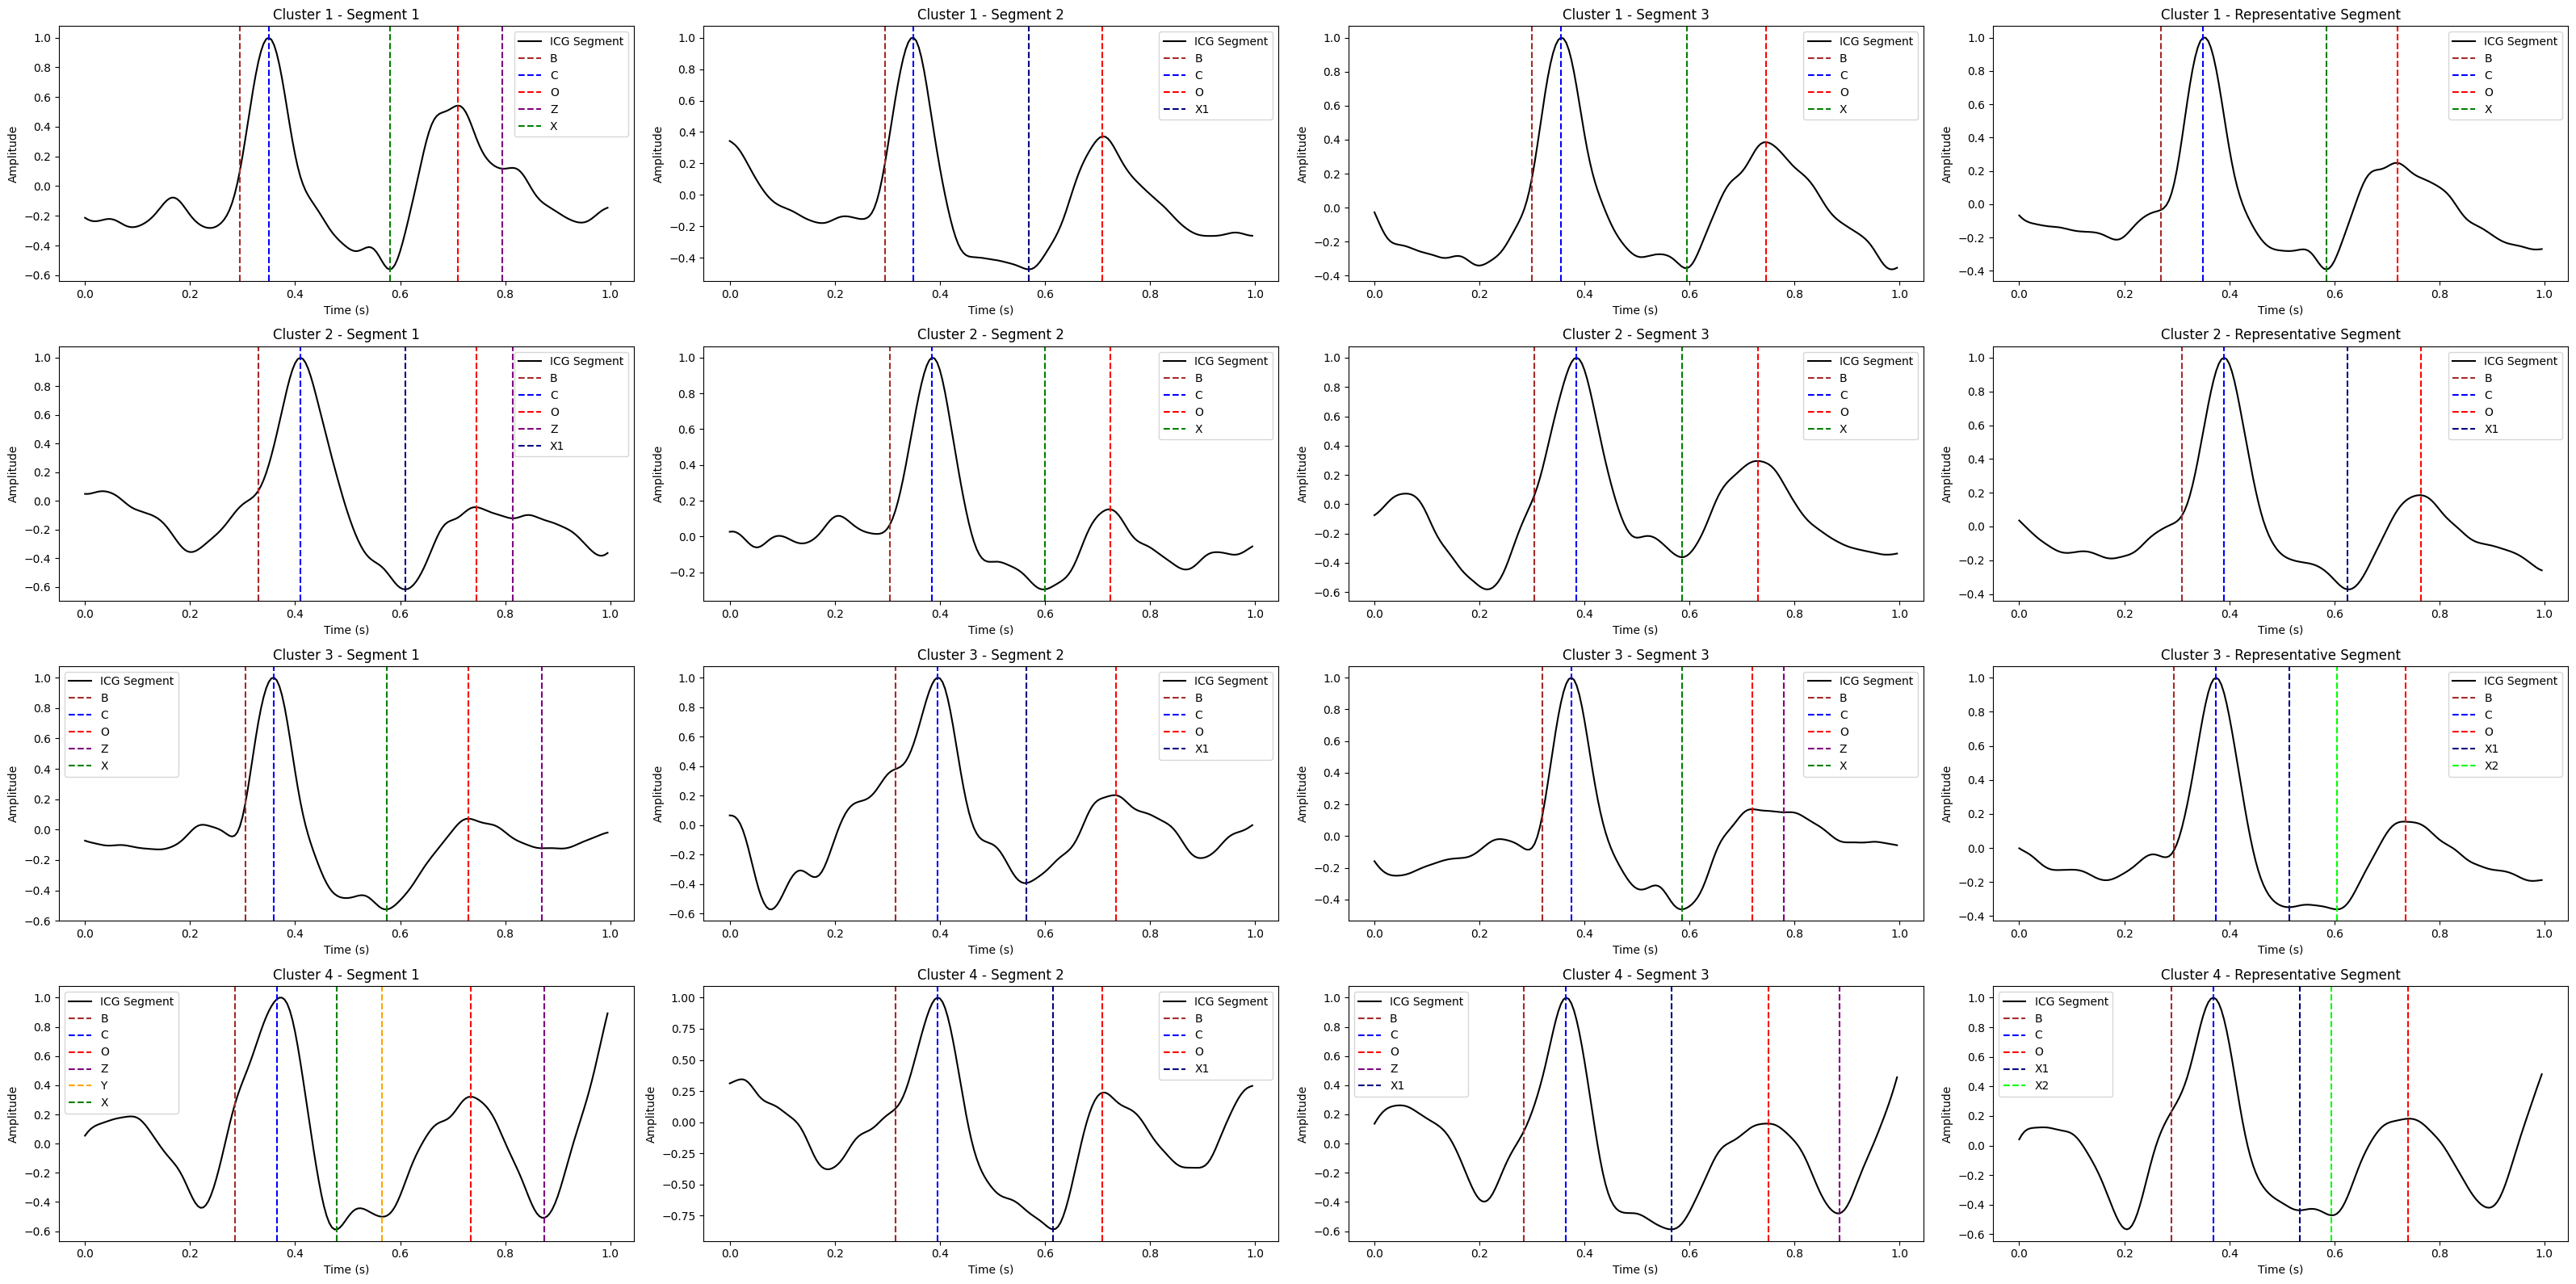

In [30]:
N = 3  # Número de segmentos a visualizar por cluster
fs = 200  # Frecuencia de muestreo

def plot_segment_with_points(ax, segment, points, fs, title=""):
    t = np.arange(len(segment)) / fs  # Vector de tiempo en segundos
    ax.plot(t, segment, label='ICG Segment', color='black')
    colors = {
        "B": "brown", "C": "blue", "X": "green", "X1": "navy", "X2": "lime",
        "O": "red", "Z": "purple", "Y": "orange"
    }
    for label, index in points.items():
        if index is not None:
            ax.axvline(index / fs, color=colors.get(label, 'black'), linestyle='--', label=label)
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')


def calculate_medoid_segment(segments):
    min_len = min(len(s) for s in segments)
    trimmed_segments = [s[:min_len] for s in segments]
    n = len(trimmed_segments)

    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(trimmed_segments[i] - trimmed_segments[j])
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist

    dist_sums = dist_matrix.sum(axis=1)
    medoid_idx = np.argmin(dist_sums)

    return trimmed_segments[medoid_idx]


num_clusters = k_manual
fig, axes = plt.subplots(num_clusters, N + 1, figsize=(8 * (N + 1), 4 * num_clusters))

for cluster_id in range(num_clusters):
    # Extraer todos los segmentos del cluster actual, eliminando valores nulos
    segments = cluster_table_manual[f'Cluster_{cluster_id}'].dropna().tolist()

    if len(segments) == 0:
        print(f"⚠️ Cluster {cluster_id} vacío.")
        continue

    # Seleccionar N segmentos aleatorios
    random.seed()
    selected_segments = random.sample(segments, min(N, len(segments)))

    # Calcular el segmento representativo
    representative_segment = calculate_medoid_segment(segments)

    # Detectar puntos característicos en el segmento representativo
    C_peaks, _ = detect_C_peaks(representative_segment, fs)
    if len(C_peaks) == 0:
        print(f"⚠️ Cluster {cluster_id}: no se detectó pico C en el segmento representativo.")
        continue
    C_index = C_peaks[0]
    B_index = find_B_point(representative_segment, C_index, fs)
    resultado_X = detectar_punto_X(representative_segment, C_index, fs)
    O_index = detect_O_point(representative_segment, C_index, fs)
    Z_index = detect_Z_point(representative_segment, O_index, fs) if O_index else None
    Y_index = detectar_punto_Y(representative_segment, resultado_X, O_index, fs)

    puntos_repr = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
    if resultado_X["caso"] == "X":
        puntos_repr["X"] = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        puntos_repr["X1"] = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        puntos_repr["X1"] = resultado_X["X1"]
        puntos_repr["X2"] = resultado_X["X2"]

    # Plot de segmentos individuales
    for i, segment in enumerate(selected_segments):
        C_peaks, _ = detect_C_peaks(segment, fs)
        if len(C_peaks) == 0:
            print(f"⚠️ Segmento en Cluster {cluster_id}: sin pico C.")
            continue
        C_index = C_peaks[0]
        B_index = find_B_point(segment, C_index, fs)
        resultado_X = detectar_punto_X(segment, C_index, fs)
        O_index = detect_O_point(segment, C_index, fs)
        Z_index = detect_Z_point(segment, O_index, fs) if O_index else None
        Y_index = detectar_punto_Y(segment, resultado_X, O_index, fs)

        puntos = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
        if resultado_X["caso"] == "X":
            puntos["X"] = resultado_X["X"]
        elif resultado_X["caso"] == "X1":
            puntos["X1"] = resultado_X["X1"]
        elif resultado_X["caso"] == "X1_X2":
            puntos["X1"] = resultado_X["X1"]
            puntos["X2"] = resultado_X["X2"]

        plot_segment_with_points(axes[cluster_id, i], segment, puntos, fs, title=f"Cluster {cluster_id+1} - Segment {i+1}")

    # Plot del segmento representativo
    plot_segment_with_points(axes[cluster_id, N], representative_segment, puntos_repr, fs, title=f"Cluster {cluster_id+1} - Representative Segment")

plt.tight_layout()
plt.show()


In [31]:
# 🔧 Define aquí el K manual deseado
k_manual = 3

print(f"\n🔁 Aplicando clustering manual con K = {k_manual}...")

# Aplica clustering con K manual
random.seed(42)
initial_medoids_manual = random.sample(range(len(X)), k_manual)
kmedoids_manual = kmedoids(dtw_distances.tolist(), initial_medoids_manual, data_type='distance_matrix')
kmedoids_manual.process()
clusters_manual = kmedoids_manual.get_clusters()

# Crear etiquetas manuales
labels_manual = np.empty(len(X), dtype=int)
for cluster_id, cluster_points in enumerate(clusters_manual):
    labels_manual[cluster_points] = cluster_id

# Crear tabla de clusters con los segmentos completos para K manual
cluster_table_manual = pd.DataFrame(columns=[f'Cluster_{i}' for i in range(k_manual)])

# Índices reales
original_indices = v_segments.index

# Asignar los segmentos completos a la tabla por cluster
for i, label in enumerate(labels_manual):
    idx = original_indices[i]
    full_segment = v_segments.loc[idx, 'icg_segment']
    row = [None] * k_manual
    row[label] = full_segment
    cluster_table_manual.loc[len(cluster_table_manual)] = row

# Mostrar resumen
print(f"✅ Tabla para K = {k_manual} generada con {len(cluster_table_manual)} filas.")
print(cluster_table_manual.head())

# Guardar en CSV con nombre personalizado
cluster_table_manual.to_csv(f'tabla_clusters_segmentos_completos_K{k_manual}.csv', index=False)



🔁 Aplicando clustering manual con K = 3...
✅ Tabla para K = 3 generada con 1657 filas.
  Cluster_0 Cluster_1                                          Cluster_2
0      None      None  [-0.0879120428378609, -0.0978801295061101, -0....
1      None      None  [-0.06942069528769894, -0.07176496233766803, -...
2      None      None  [-0.059054204545974404, -0.06793791125007255, ...
3      None      None  [-0.016860400336395357, -0.024696119334679554,...
4      None      None  [-0.11504064068538182, -0.12164844524542653, -...



📊 Segment Distribution in Clusters


Cluster,number of segments,total %
Cluster_0,782,47.2%
Cluster_1,332,20.0%
Cluster_2,543,32.8%


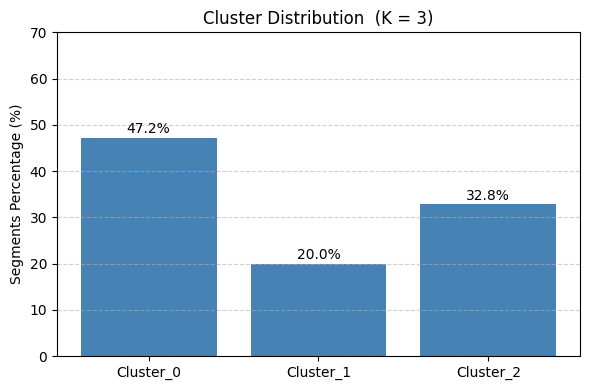

In [32]:
# ============================================================
# 🔎  Distribución de segmentos por cluster  (tabla + gráfico)
# ============================================================

# 1. Conteos absolutos y porcentajes -------------------------
cluster_counts = cluster_table_manual.count()           # nº de segmentos por columna
cluster_perc   = 100 * cluster_counts / cluster_counts.sum()

dist_df = pd.DataFrame({
    "Cluster": cluster_counts.index,
    "number of segments": cluster_counts.values,
    "total %": cluster_perc.round(1)
})

# 2. Mostrar la tabla formateada -----------------------------
print("\n📊 Segment Distribution in Clusters")
display(  # si usas Jupyter; si no, usa print(dist_df.to_string(index=False))
    dist_df.style
        .hide(axis="index")
        .set_table_styles([{"selector":"th","props":[("text-align","center")]}])
        .format({"total %": "{:.1f}%"})
)

# 3. Gráfico de barras ---------------------------------------
plt.figure(figsize=(6,4))
plt.bar(dist_df["Cluster"], dist_df["total %"], color="steelblue")
plt.ylabel("Segments Percentage (%)")
plt.title(f"Cluster Distribution  (K = {k_manual})")
plt.ylim(0, 70)
plt.grid(axis="y", linestyle="--", alpha=0.6)
for x, pct in zip(dist_df["Cluster"], dist_df["total %"]):
    plt.text(x, pct + 1, f"{pct:.1f}%", ha="center")
plt.tight_layout()
plt.show()


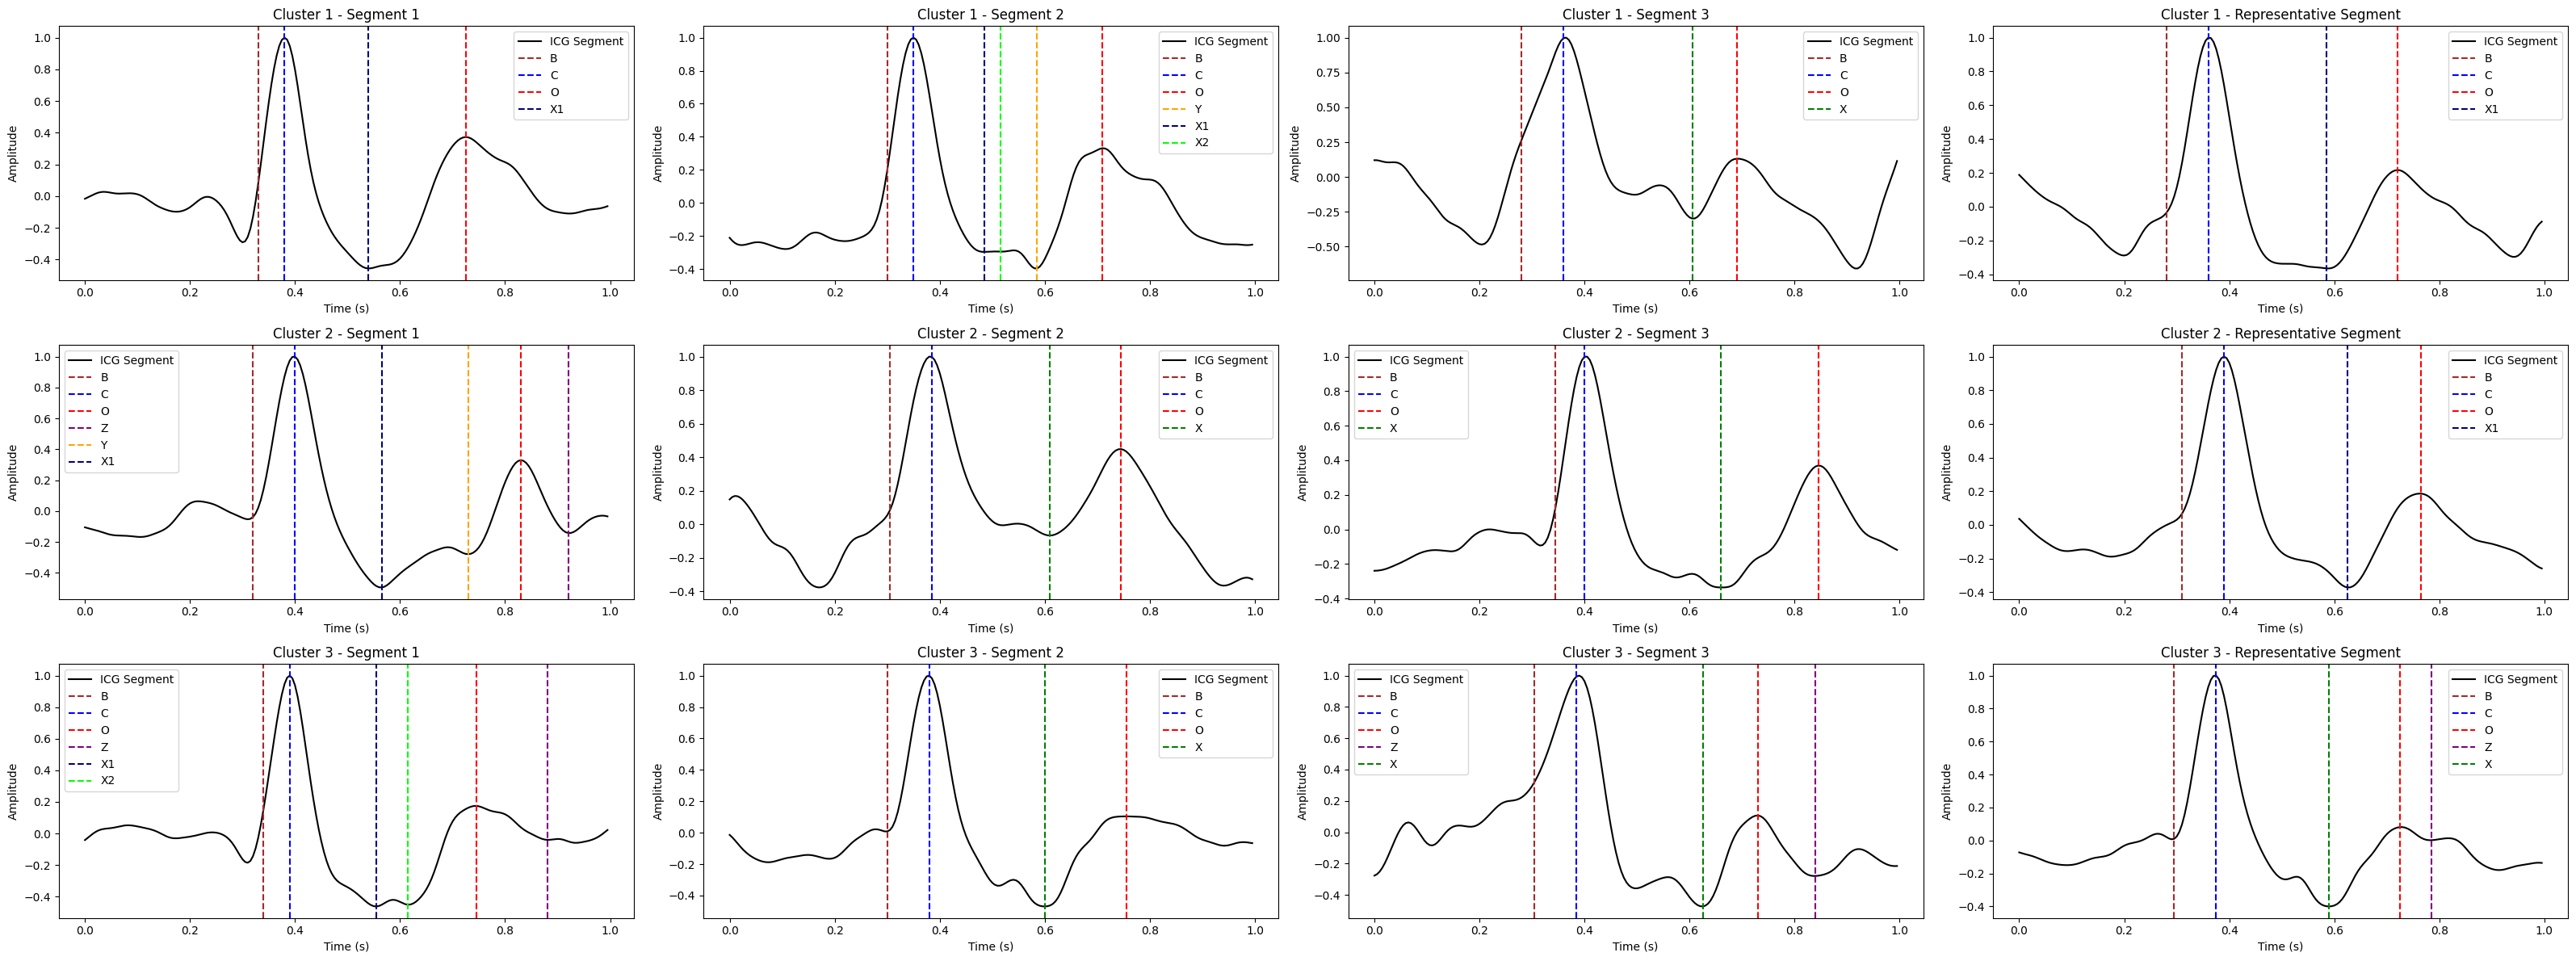

In [33]:
N = 3  # Número de segmentos a visualizar por cluster
fs = 200  # Frecuencia de muestreo

def plot_segment_with_points(ax, segment, points, fs, title=""):
    t = np.arange(len(segment)) / fs  # Vector de tiempo en segundos
    ax.plot(t, segment, label='ICG Segment', color='black')
    colors = {
        "B": "brown", "C": "blue", "X": "green", "X1": "navy", "X2": "lime",
        "O": "red", "Z": "purple", "Y": "orange"
    }
    for label, index in points.items():
        if index is not None:
            ax.axvline(index / fs, color=colors.get(label, 'black'), linestyle='--', label=label)
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')


def calculate_medoid_segment(segments):
    min_len = min(len(s) for s in segments)
    trimmed_segments = [s[:min_len] for s in segments]
    n = len(trimmed_segments)

    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(trimmed_segments[i] - trimmed_segments[j])
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist

    dist_sums = dist_matrix.sum(axis=1)
    medoid_idx = np.argmin(dist_sums)

    return trimmed_segments[medoid_idx]


num_clusters = k_manual
fig, axes = plt.subplots(num_clusters, N + 1, figsize=(8 * (N + 1), 4 * num_clusters))

for cluster_id in range(num_clusters):
    # Extraer todos los segmentos del cluster actual, eliminando valores nulos
    segments = cluster_table_manual[f'Cluster_{cluster_id}'].dropna().tolist()

    if len(segments) == 0:
        print(f"⚠️ Cluster {cluster_id} vacío.")
        continue

    # Seleccionar N segmentos aleatorios
    random.seed()
    selected_segments = random.sample(segments, min(N, len(segments)))

    # Calcular el segmento representativo
    representative_segment = calculate_medoid_segment(segments)

    # Detectar puntos característicos en el segmento representativo
    C_peaks, _ = detect_C_peaks(representative_segment, fs)
    if len(C_peaks) == 0:
        print(f"⚠️ Cluster {cluster_id}: no se detectó pico C en el segmento representativo.")
        continue
    C_index = C_peaks[0]
    B_index = find_B_point(representative_segment, C_index, fs)
    resultado_X = detectar_punto_X(representative_segment, C_index, fs)
    O_index = detect_O_point(representative_segment, C_index, fs)
    Z_index = detect_Z_point(representative_segment, O_index, fs) if O_index else None
    Y_index = detectar_punto_Y(representative_segment, resultado_X, O_index, fs)

    puntos_repr = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
    if resultado_X["caso"] == "X":
        puntos_repr["X"] = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        puntos_repr["X1"] = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        puntos_repr["X1"] = resultado_X["X1"]
        puntos_repr["X2"] = resultado_X["X2"]

    # Plot de segmentos individuales
    for i, segment in enumerate(selected_segments):
        C_peaks, _ = detect_C_peaks(segment, fs)
        if len(C_peaks) == 0:
            print(f"⚠️ Segmento en Cluster {cluster_id}: sin pico C.")
            continue
        C_index = C_peaks[0]
        B_index = find_B_point(segment, C_index, fs)
        resultado_X = detectar_punto_X(segment, C_index, fs)
        O_index = detect_O_point(segment, C_index, fs)
        Z_index = detect_Z_point(segment, O_index, fs) if O_index else None
        Y_index = detectar_punto_Y(segment, resultado_X, O_index, fs)

        puntos = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
        if resultado_X["caso"] == "X":
            puntos["X"] = resultado_X["X"]
        elif resultado_X["caso"] == "X1":
            puntos["X1"] = resultado_X["X1"]
        elif resultado_X["caso"] == "X1_X2":
            puntos["X1"] = resultado_X["X1"]
            puntos["X2"] = resultado_X["X2"]

        plot_segment_with_points(axes[cluster_id, i], segment, puntos, fs, title=f"Cluster {cluster_id+1} - Segment {i+1}")

    # Plot del segmento representativo
    plot_segment_with_points(axes[cluster_id, N], representative_segment, puntos_repr, fs, title=f"Cluster {cluster_id+1} - Representative Segment")

plt.tight_layout()
plt.show()
